In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from collections import defaultdict
import pandas as pd
from typing import Dict, List, Union, Optional, Tuple, TypedDict
import matplotlib.font_manager as fm

from pathlib import Path
import seaborn as sns
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl

font_path = "/System/Library/Fonts/Supplemental/Times New Roman.ttf"

times_new_roman = fm.FontProperties(fname=font_path, size=18)
prop = fm.FontProperties(fname=font_path, size=18)
# Apply globally via rcParams
plt.rcParams['font.family'] = times_new_roman.get_name()


# # Draw a nested boxplot to show bills by day and time
# plt.figure(figsize=(10, 3))  # width=10, height=6 inches
sns.set(style="whitegrid")  # Clean background
sns.set(rc={
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "font.size": 18,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
sns.set_context("paper", font_scale=1)

palette = sns.color_palette("Set2")  # Or "muted", "colorblind", etc.

mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300

print(f"colors: {palette}")

colors: [(0.4, 0.7607843137254902, 0.6470588235294118), (0.9882352941176471, 0.5529411764705883, 0.3843137254901961), (0.5529411764705883, 0.6274509803921569, 0.796078431372549), (0.9058823529411765, 0.5411764705882353, 0.7647058823529411), (0.6509803921568628, 0.8470588235294118, 0.32941176470588235), (1.0, 0.8509803921568627, 0.1843137254901961), (0.8980392156862745, 0.7686274509803922, 0.5803921568627451), (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]


### RQ1 - Updated Figure 2

Processing project: rxjava
Processing project: eclipse-collections
Processing project: zipkin


/var/folders/0g/r44s72rx3nb5_rbtvsg9v6wr0000gn/T/ipykernel_25162/3271789056.py:79: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(x="Subject", y="RSD (%)", hue="Method", showfliers=False,


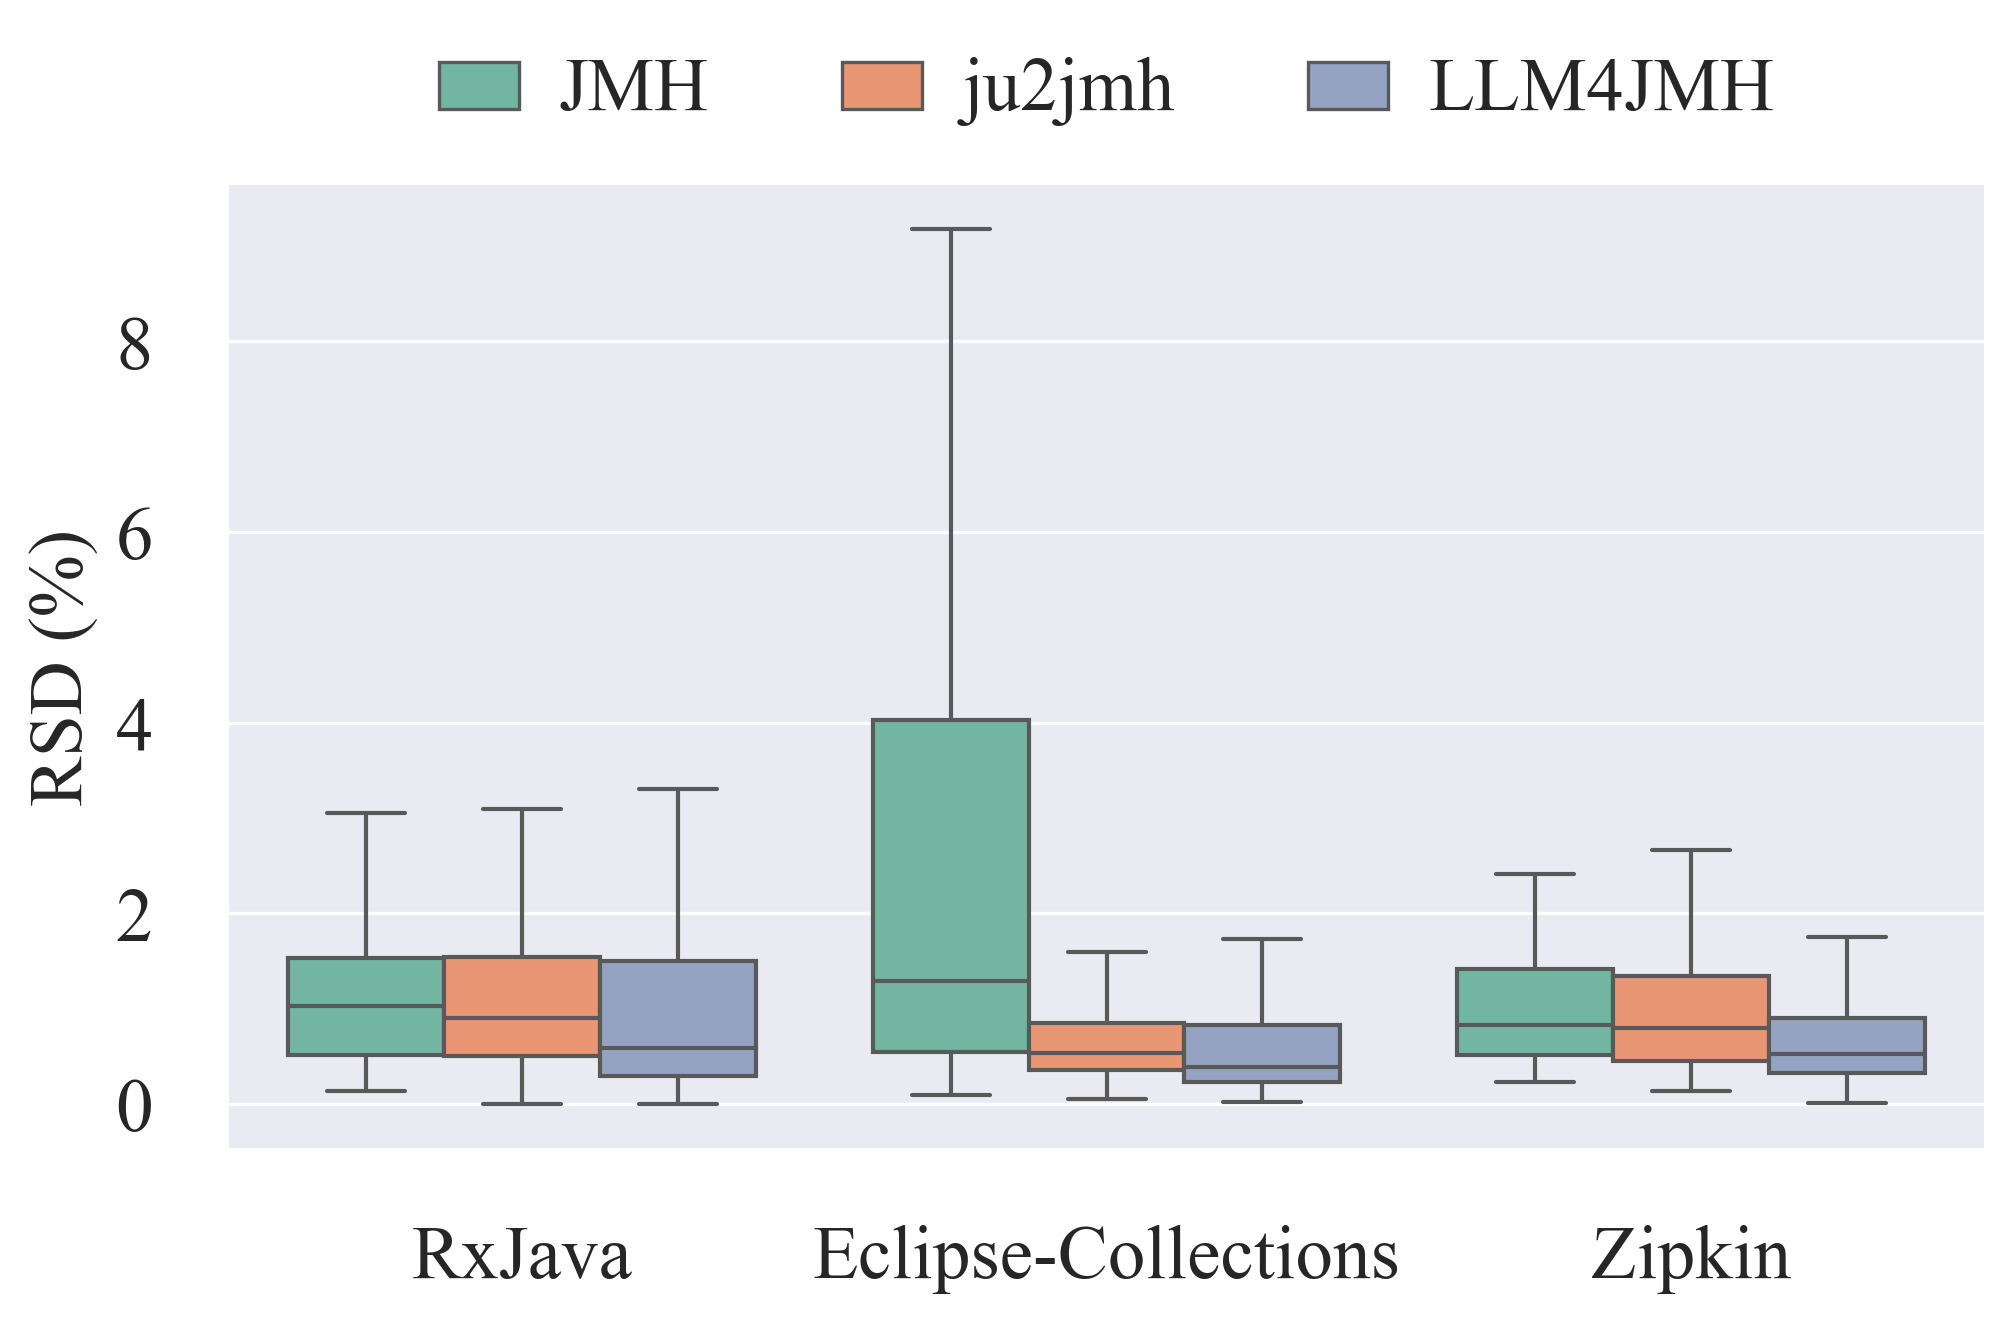

In [ ]:
import json
from pathlib import Path
import pandas as pd
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

import numpy as np
from pathlib import Path
import json 

import seaborn as sns
import matplotlib.pyplot as plt

def get_rsd_list(project: str, branch: str):
    df = pd.read_csv(f'../Data/RQ1/{project}-{branch}.csv')
    rsd_list = []
    for i, row in df.iterrows():
        thrpts = [row[f'Iteration {i}'] for i in range(30)]
        # if len(thrpts) != 30:
        #     import ipdb; ipdb.set_trace()
        # rsd = np.std(thrpts) / np.mean(thrpts) * 100
        median = np.median(thrpts)
        mad = np.median(np.abs(thrpts - median))
        # Scale MAD to be comparable with standard deviation for normal data
        robust_std = 1.4826 * mad
        rsd = robust_std / median * 100 
        
        rsd_list.append(rsd)

    return np.array(rsd_list)

def get_rsd_data() -> pd.DataFrame:
    data = {  
        'Subject': [],
        'Method': [],
        'RSD (%)': [],      
     }    
    for project in ['rxjava', 'eclipse-collections', 'zipkin']:      
        print(f'Processing project: {project}')
        mapped_project = {
            'rxjava': 'RxJava', 
            'eclipse-collections': 'Eclipse-Collections',
            'zipkin': 'Zipkin',
        }
        jmh = get_rsd_list(project, 'JMH')
        ju2jmh = get_rsd_list(project, 'ju2jmh')
        llm2jmh = get_rsd_list(project, 'LLM4JMH')        

        data['Subject'].extend([mapped_project[project]]* len(jmh))
        data['Method'].extend(['JMH'] * len(jmh))
        data['RSD (%)'].extend(jmh)
        data['Subject'].extend([mapped_project[project]] * len(ju2jmh))
        data['Method'].extend(['ju2jmh'] * len(ju2jmh))
        data['RSD (%)'].extend(ju2jmh)
        data['Subject'].extend([mapped_project[project]] * len(llm2jmh))
        data['Method'].extend(['LLM4JMH'] * len(llm2jmh))
        data['RSD (%)'].extend(llm2jmh)
       
    df = pd.DataFrame(data)
    return df

df = get_rsd_data()

sns.set(style="whitegrid")  # Clean background
sns.set(rc={
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "font.size": 18,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
sns.set_context("paper", font_scale=1)

fig, ax = plt.subplots(figsize=(6.8, 4.5))
sns.boxplot(x="Subject", y="RSD (%)", hue="Method", showfliers=False,
            data=df, palette=palette)
sns.despine(offset=10, trim=True)
plt.xlabel("", fontsize=8)
sns.move_legend(
    ax, "lower center", fontsize=16,
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
    handletextpad=0.6, handlelength=1.2
)
legend = ax.get_legend()
legend.set_title(legend.get_title().get_text(), prop=times_new_roman)
for text in legend.get_texts():
    text.set_fontproperties(times_new_roman)

plt.ylabel("RSD (%)", fontproperties=prop)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_new_roman)

plt.tight_layout()
plt.show()

### RQ1: Updated Table 2

In [ ]:
import json
from pathlib import Path
import pandas as pd
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

import numpy as np
from pathlib import Path
import json 

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def check_stable_unstable_cases(all_cases, name):
    stable = all_cases[all_cases <= 1]
    unstable = all_cases[all_cases >= 5]
    print(f"{name}\t: stable: {stable.shape[-1]/all_cases.shape[-1]*100:.2f} %, \tUnstable: {unstable.shape[-1]/all_cases.shape[-1]*100:.2f} %")

def get_rsd_list(project: str, branch: str):
    df = pd.read_csv(f'../Data/RQ1/{project}-{branch}.csv')
    rsd_list = []
    for i, row in df.iterrows():
        thrpts = [row[f'Iteration {i}'] for i in range(30)]
        if len(thrpts) != 30:
            import ipdb; ipdb.set_trace()
        rsd = np.std(thrpts) / np.mean(thrpts) * 100
        rsd_list.append(rsd)

    return np.array(rsd_list)

def get_rsd_data() -> pd.DataFrame:    
    for project in ['rxjava', 'eclipse-collections', 'zipkin']:      
        mapped_project = {
            'rxjava': 'RxJava', 
            'eclipse-collections': 'Eclipse-Collections',
            'zipkin': 'Zipkin',
        }
        jmh = get_rsd_list(project, 'JMH')
        ju2jmh = get_rsd_list(project, 'ju2jmh')
        llm2jmh = get_rsd_list(project, 'LLM4JMH')        

        check_stable_unstable_cases(jmh, f'{mapped_project[project]} JMH')
        check_stable_unstable_cases(ju2jmh, f'{mapped_project[project]} ju2jmh')
        check_stable_unstable_cases(llm2jmh, f'{mapped_project[project]} LLM4JMH')
       
get_rsd_data()

RxJava JMH	: stable: 23.77 %, 	Unstable: 5.02 %
RxJava ju2jmh	: stable: 37.11 %, 	Unstable: 23.92 %
RxJava LLM4JMH	: stable: 43.15 %, 	Unstable: 8.07 %
Eclipse-Collections JMH	: stable: 27.83 %, 	Unstable: 25.87 %
Eclipse-Collections ju2jmh	: stable: 73.08 %, 	Unstable: 0.88 %
Eclipse-Collections LLM4JMH	: stable: 63.70 %, 	Unstable: 8.89 %
Zipkin JMH	: stable: 40.98 %, 	Unstable: 1.64 %
Zipkin ju2jmh	: stable: 48.08 %, 	Unstable: 1.22 %
Zipkin LLM4JMH	: stable: 70.21 %, 	Unstable: 5.14 %


# RQ1: Figure 3 (RxJava). The box-plots of calculated RCIW for all benchmark suites.

In [ ]:
import json
from pathlib import Path
import pandas as pd
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project_to_ylim = {
    'rxjava': 0.14,
    'eclipse-collections': 0.18,
    'zipkin': 0.04,
}

def get_data(project: str) -> pd.DataFrame:
    rciw_path = Path(f'../Data/RQ1ew/{project}-RCIW-median.json')
    with open(rciw_path, 'r') as fp:
        branch_to_rciws_list = json.load(fp)
    data = {
        'Method': [],
        'RCIW': [],
        'Number of iterations': [],
    }

    for i in range(14):
        for branch, rciws_list in branch_to_rciws_list.items(): 
            if branch == 'jmh-tests':
                branch = 'jmh'
            if branch == 'benchmarks':
                branch = 'jmh'
            for rciws in rciws_list:                    
                if len(rciws) < 29:
                    continue
                data['Number of iterations'].append(i + 2)
                    
                if branch == 'llm2jmh':
                    data['Method'].append('LLM4JMH')
                    data['RCIW'].append(rciws[i])                
                elif branch == 'jmh':
                    data['Method'].append('JMH')
                    data['RCIW'].append(rciws[i])
                else:
                    data['Method'].append(branch)
                    data['RCIW'].append(rciws[i])
    df = pd.DataFrame(data)
    return df

def plot_rciw(project: str):
    df = get_data(project)
    palette = sns.color_palette("Set2")  # Or "muted", "colorblind", etc.
    sns.set(style="whitegrid")  # Clean background
    sns.set(rc={
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 18,
        "font.size": 18,
        "figure.dpi": 300,
        "savefig.dpi": 300
    })
    sns.set_context("paper", font_scale=1)
    
    fig, ax = plt.subplots(figsize=(10, 1.6))

    sns.boxplot(x="Number of iterations", y="RCIW", hue="Method",  showfliers=False,
                data=df, palette=palette)
    sns.despine(offset=10, trim=True)
    plt.legend(
        bbox_to_anchor=(1.01, 0.5),  # Outside to the right
        loc='center left',
        borderaxespad=0.,
        frameon=True,
        fontsize=12,
        handlelength=0.6,    # Reduce handle length
        handleheight=0.6,    # Reduce height
    )

    font_path = "/System/Library/Fonts/Supplemental/Times New Roman.ttf"
    times_new_roman = fm.FontProperties(fname=font_path, size=14)
    prop = fm.FontProperties(fname=font_path, size=14)
    # Apply globally via rcParams
    plt.rcParams['font.family'] = times_new_roman.get_name()
    plt.xlabel("Number of iterations", fontproperties=prop)
    plt.ylabel("RSD (%)", fontproperties=prop)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(times_new_roman)

    plt.tight_layout()
    plt.ylim(0, project_to_ylim[project])
    plt.tight_layout()
    plt.show()

### RQ1: Updated Figure 3 (RxJava). The box-plots of calculated RCIW for all benchmark suites.

/var/folders/0g/r44s72rx3nb5_rbtvsg9v6wr0000gn/T/ipykernel_35033/2689020912.py:145: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(x="Number of iterations", y="RCIW", hue="Method",  showfliers=False,


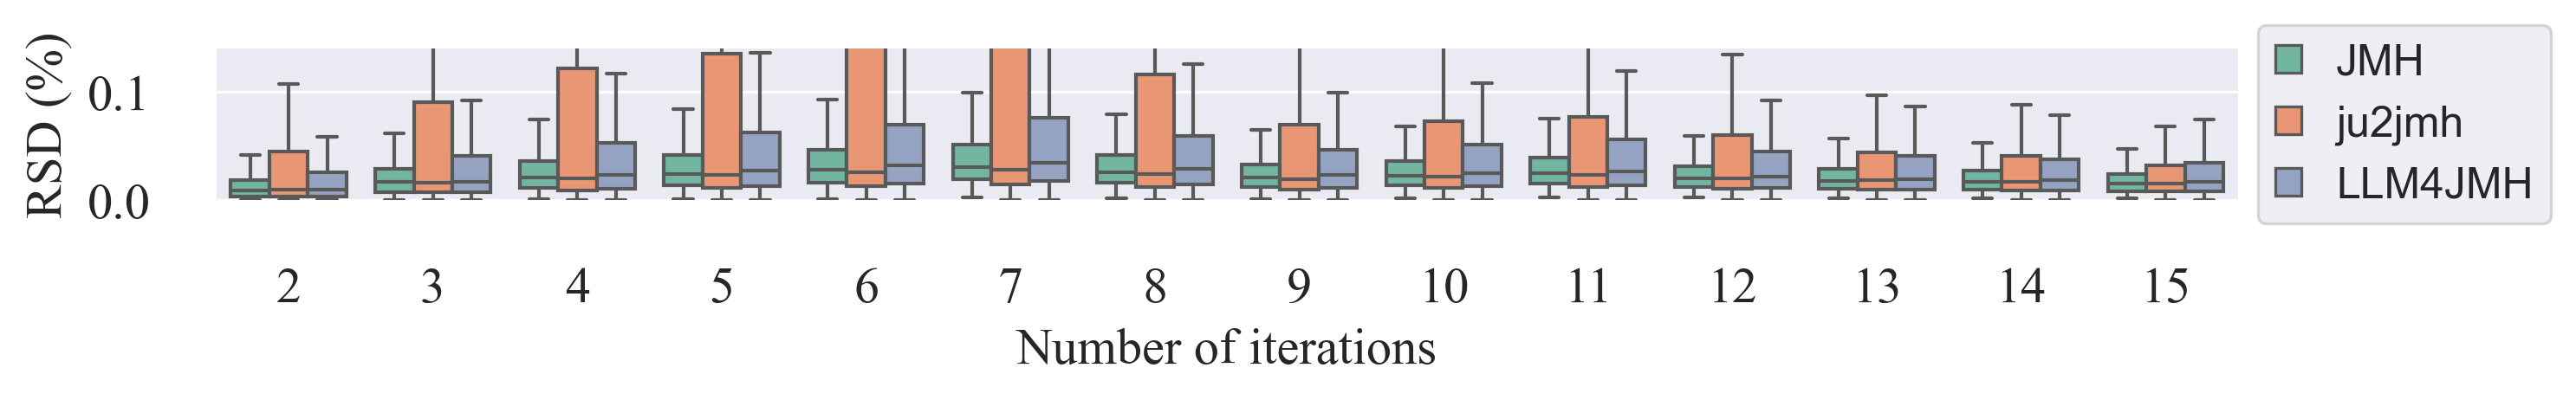

In [10]:
# RxJava RCIW
project = 'rxjava'
plot_rciw(project)

### RQ1: Figure 3 (Eclipse-Collections). The box-plots of calculated RCIW for all benchmark suites.

/var/folders/0g/r44s72rx3nb5_rbtvsg9v6wr0000gn/T/ipykernel_35033/2689020912.py:145: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(x="Number of iterations", y="RCIW", hue="Method",  showfliers=False,


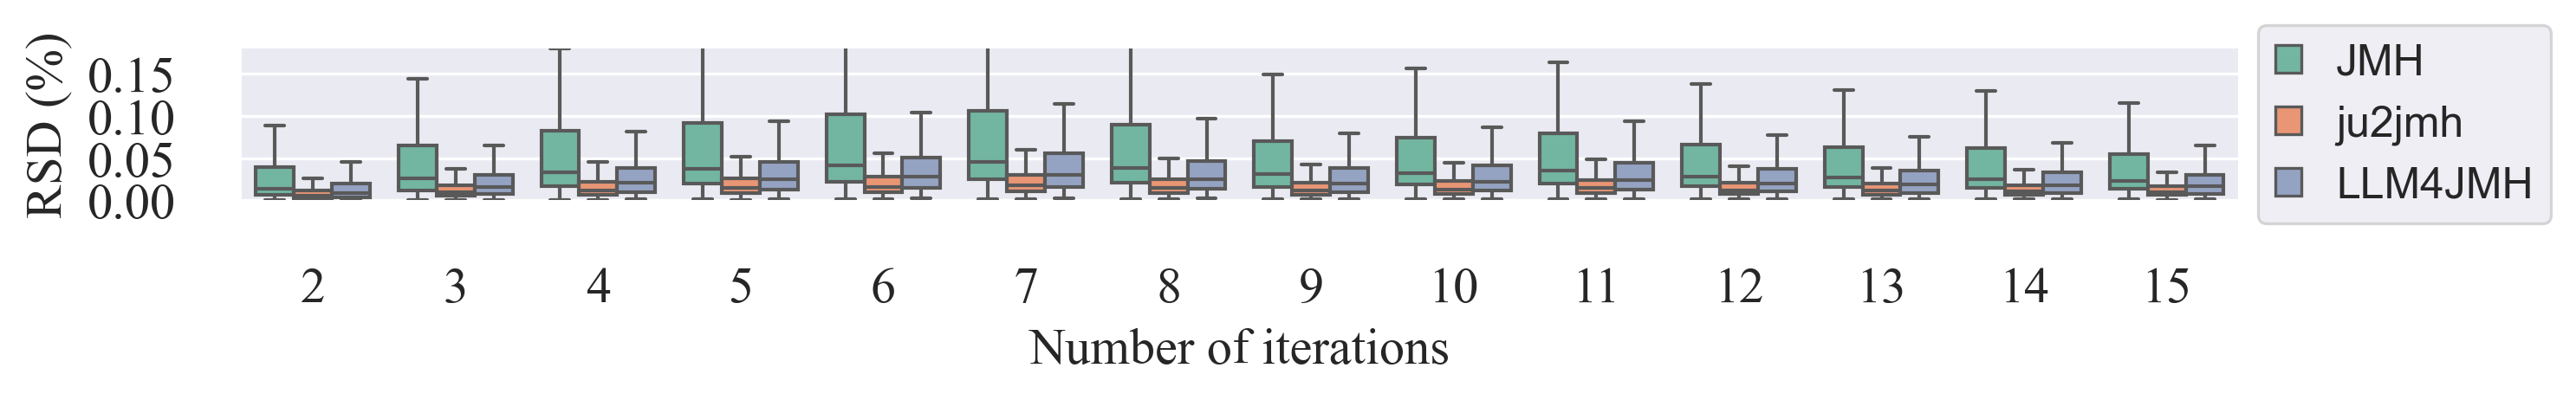

In [11]:
# RxJava RCIW
project = 'eclipse-collections'
plot_rciw(project)

### RQ1: Figure 3 (Zipkin). The box-plots of calculated RCIW for all benchmark suites.

/var/folders/0g/r44s72rx3nb5_rbtvsg9v6wr0000gn/T/ipykernel_35033/2689020912.py:145: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(x="Number of iterations", y="RCIW", hue="Method",  showfliers=False,


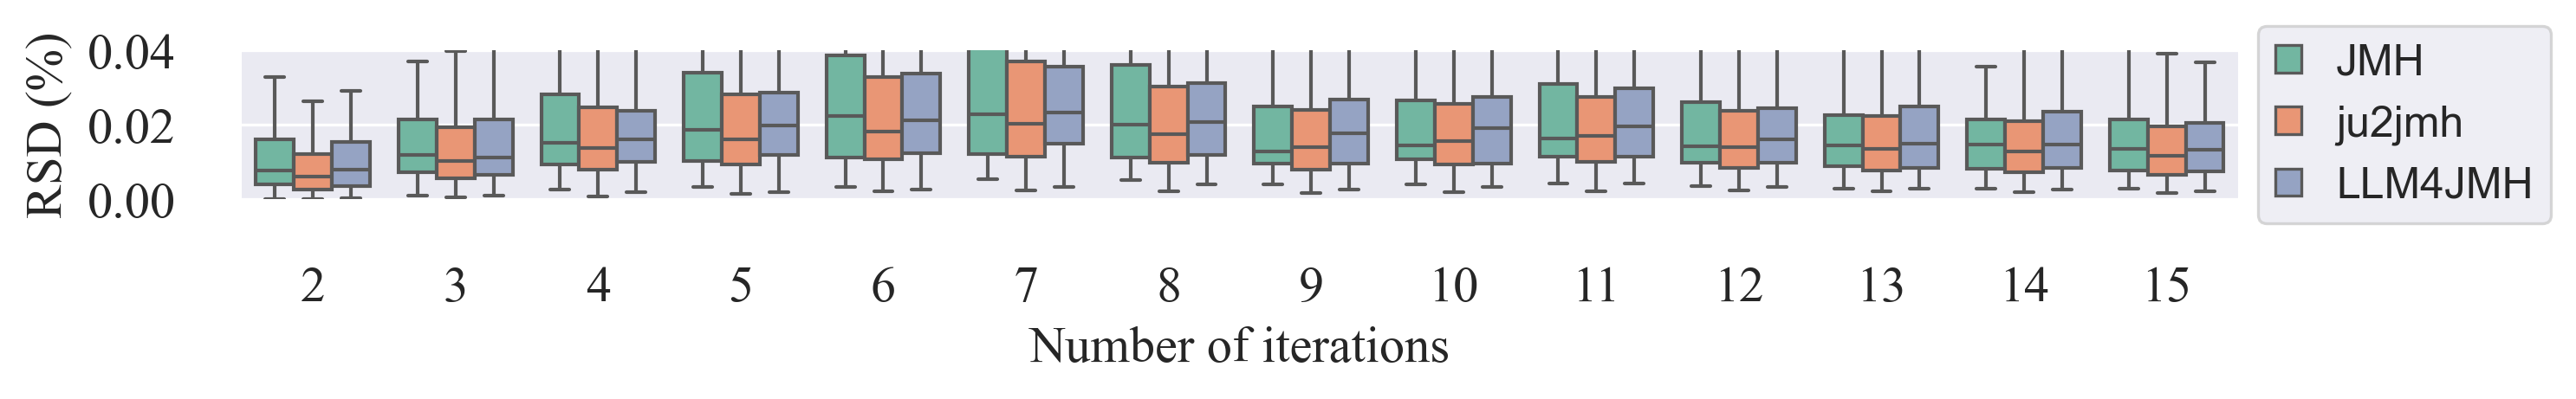

In [12]:
# RxJava RCIW
project = 'zipkin'
plot_rciw(project)

### RQ2: Figure 4. Analysis of static code features for LLM-generated microbenchmarks in RxJava: (left) distribution of LOC in transitive call graph; (right) distribution of distinct method invocations

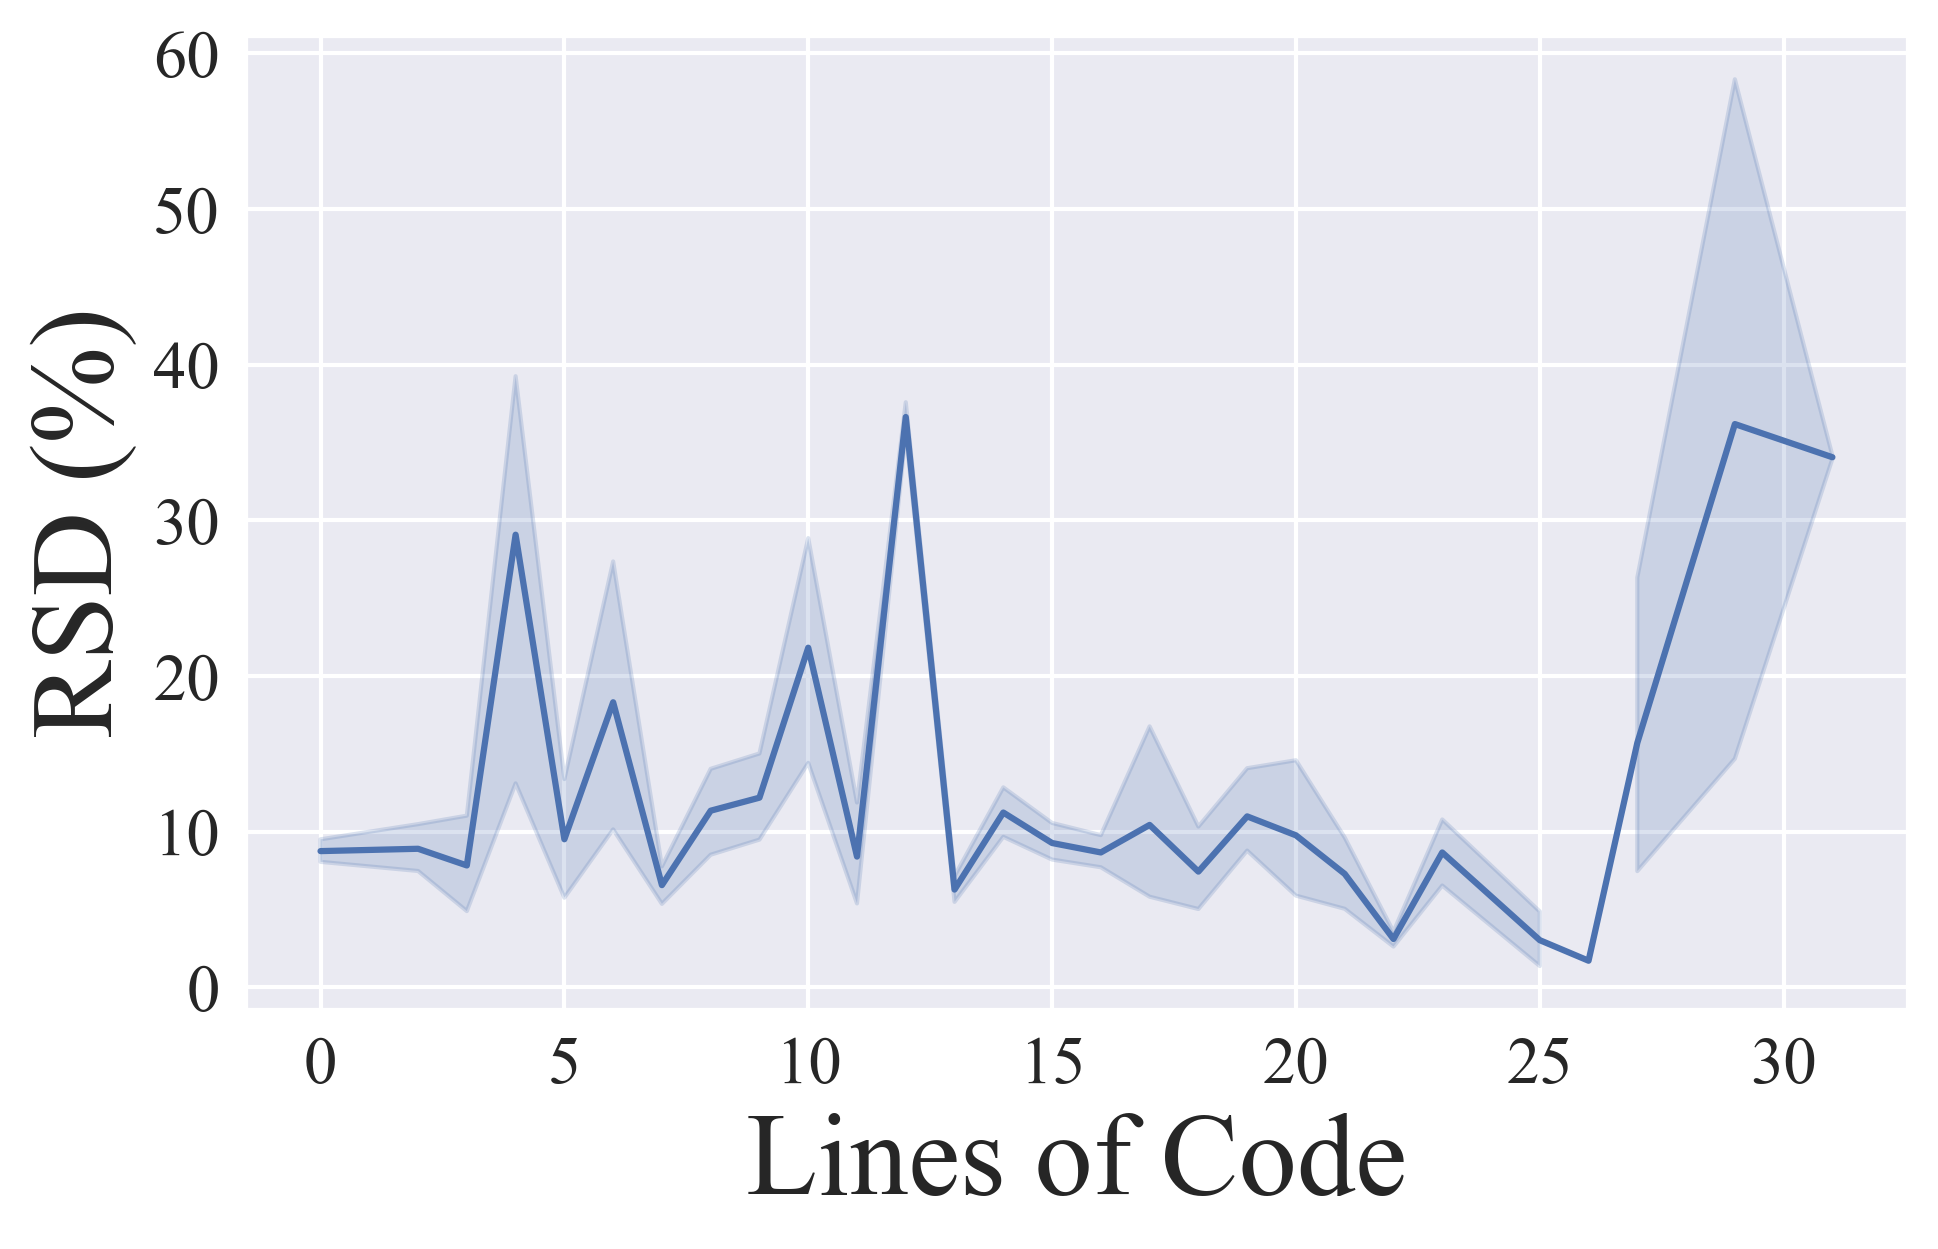

In [59]:
import matplotlib.font_manager as fm
font_path = "/System/Library/Fonts/Supplemental/Times New Roman.ttf"

project = 'rxjava'
features_path = Path(f'../Data/RQ2/rxjava-features.jsonl')
df = pd.read_json(features_path, lines=True)
df.to_json("../Data/RQ2/rxjava-features.jsonl", orient="records", lines=True)
sns.set(style="whitegrid")  # Clean background
sns.set(rc={
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "font.size": 18,
    "figure.dpi": 300,
    "savefig.dpi": 300
})

times_new_roman = fm.FontProperties(fname=font_path, size=20)
prop = fm.FontProperties(fname=font_path, size=28)
plt.rcParams['font.family'] = times_new_roman.get_name()

fig, ax = plt.subplots(figsize=(6.8, 4.5))  
sns.lineplot(data=df, x='call_graph_loc', y='rsd', markers=True, dashes=False, ax=ax)
plt.tick_params(axis='x', pad=0)
plt.tick_params(axis='y', pad=0)
plt.ylabel("RSD (%)", fontproperties=prop)
plt.xlabel("Lines of Code", fontproperties=prop)

plt.tight_layout()
plt.show()

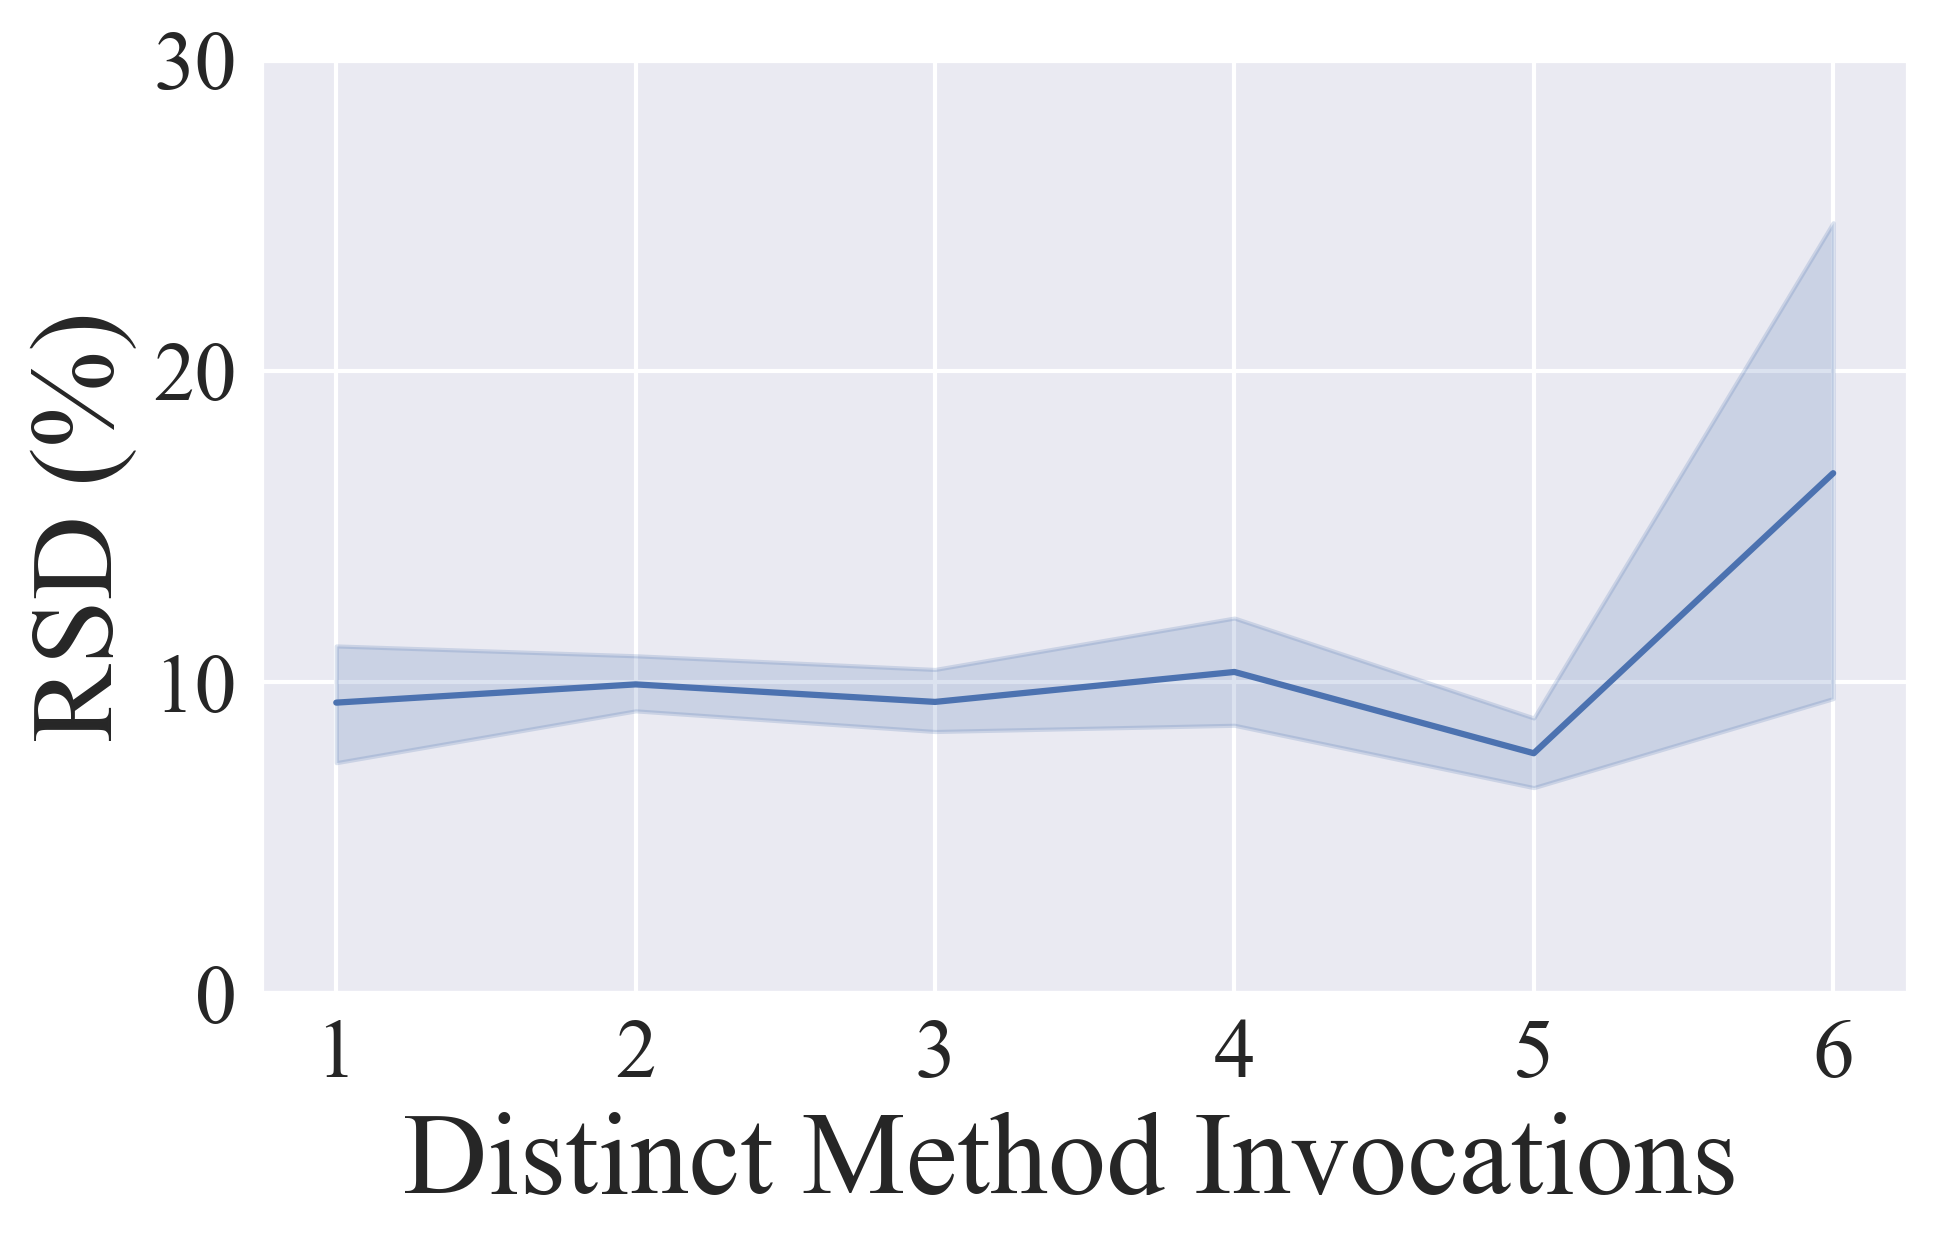

In [61]:
import matplotlib.font_manager as fm
font_path = "/System/Library/Fonts/Supplemental/Times New Roman.ttf"

project = 'rxjava'
features_path = Path(f'../Data/RQ2/{project}-features.jsonl')
df = pd.read_json(features_path, lines=True)
df.to_json(f"../Data/RQ2/{project}-features.jsonl", orient="records", lines=True)
sns.set(style="whitegrid")  # Clean background
sns.set(rc={
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "font.size": 18,
    "figure.dpi": 300,
    "savefig.dpi": 300
})

times_new_roman = fm.FontProperties(fname=font_path, size=20)
prop = fm.FontProperties(fname=font_path, size=28)
plt.rcParams['font.family'] = times_new_roman.get_name()

fig, ax = plt.subplots(figsize=(6.8, 4.5))  

sns.lineplot(data=df, x='distinct_call_cnt', y='rsd', markers=True, dashes=False, ax=ax)

plt.tick_params(axis='x', pad=0)
plt.tick_params(axis='y', pad=0)
plt.ylabel("RSD (%)", fontproperties=prop)
plt.xlabel("Distinct Method Invocations ", fontproperties=prop)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_new_roman)

plt.yticks([0, 10, 20, 30])
plt.tight_layout()
plt.show()

### RQ2: Figure 5. Impact of domain knowledge selection on the stability of LLM-generated microbenchmarks, using RSD (in %).

Processing project: rxjava
Processing project: eclipse-collections
Processing project: zipkin


/var/folders/0g/r44s72rx3nb5_rbtvsg9v6wr0000gn/T/ipykernel_6880/3336691514.py:94: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(x="Subject", y="RSD (%)", hue="Method", showfliers=False,


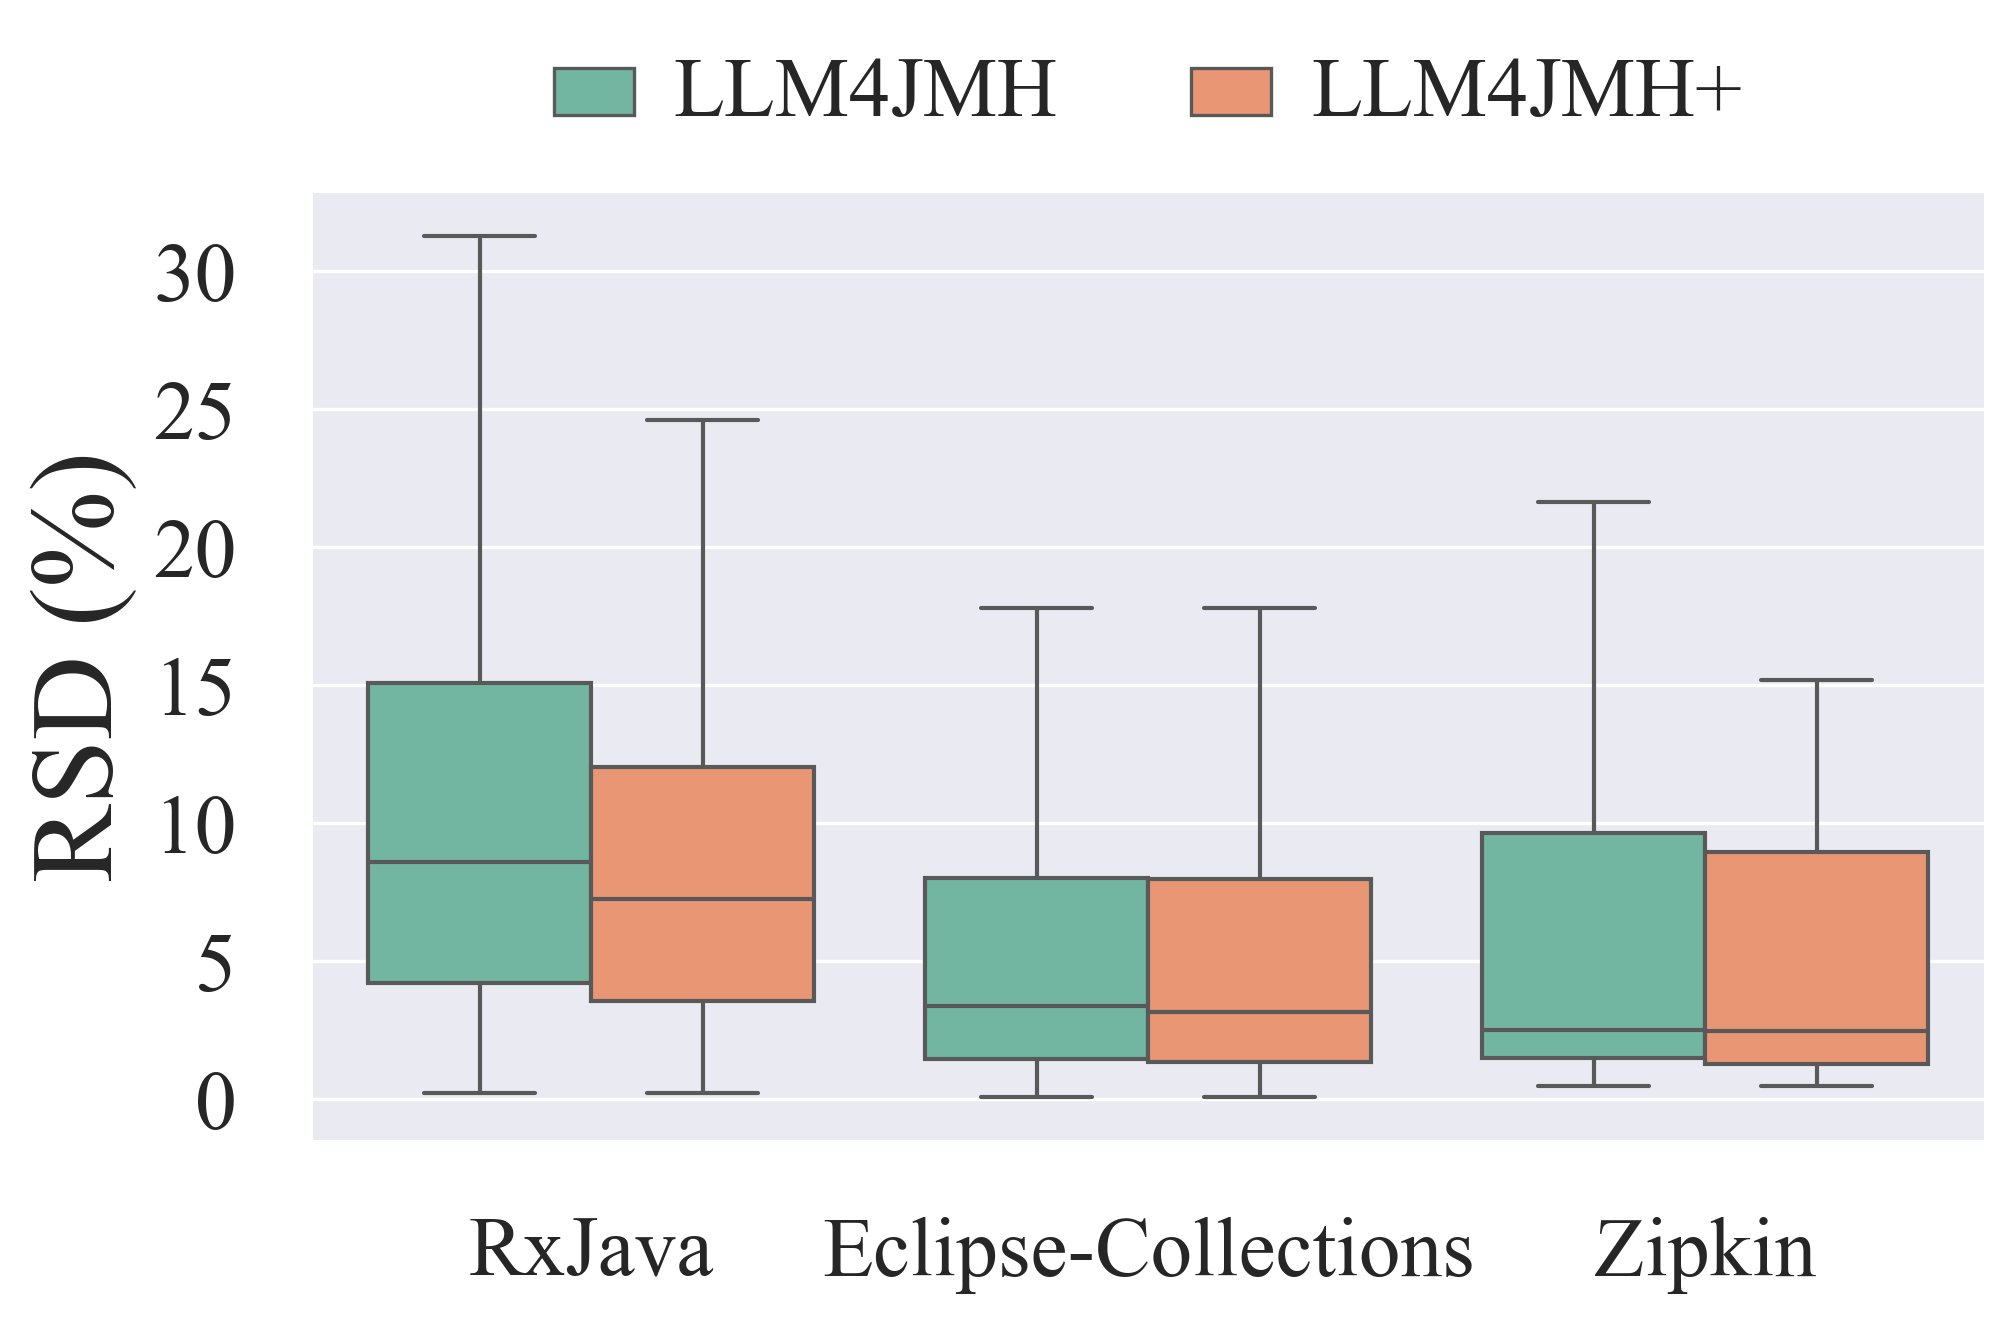

In [ ]:
import json
from pathlib import Path
import pandas as pd
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

import numpy as np
from pathlib import Path
import json 

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


def get_feature_df(project: str) -> pd.DataFrame:    
    features_path = Path(f'../Data/RQ2/{project}-features.jsonl')
    df = pd.read_json(features_path, lines=True)
    return df

def get_rsd_list(project: str, branch: str):
    df = pd.read_csv(f'../Data/RQ1/{project}-{branch}.csv')
    rsd_list = []
    for i, row in df.iterrows():
        thrpts = [row[f'Iteration {i}'] for i in range(30)]
        if len(thrpts) != 30:
            import ipdb; ipdb.set_trace()
        rsd = np.std(thrpts) / np.mean(thrpts) * 100
        rsd_list.append(rsd)

    return np.array(rsd_list)

def get_selected_rsd_list(project: str, branch: str):
    features = get_feature_df(project)
    features_copied = features[features['call_graph_loc'] <= 25]
    selected_benchmarks = features_copied['name'].to_list()    
    df = pd.read_csv(f'../Data/RQ1/{project}-{branch}.csv')
    rsd_list = []
    for i, row in df.iterrows():
        if row['benchmark'] not in selected_benchmarks:
            continue
        thrpts = [row[f'Iteration {i}'] for i in range(30)]
        if len(thrpts) != 30:
            import ipdb; ipdb.set_trace()
        rsd = np.std(thrpts) / np.mean(thrpts) * 100
        rsd_list.append(rsd)

    return np.array(rsd_list)

def get_rsd_data() -> pd.DataFrame:
    data = {  
        'Subject': [],
        'Method': [],
        'RSD (%)': [],      
     }    
    for project in ['rxjava', 'eclipse-collections', 'zipkin']:      
        print(f'Processing project: {project}')
        mapped_project = {
            'rxjava': 'RxJava', 
            'eclipse-collections': 'Eclipse-Collections',
            'zipkin': 'Zipkin',
        }
        llm2jmh = get_rsd_list(project, 'LLM4JMH')        
        llm2jmh_selected = get_selected_rsd_list(project, 'LLM4JMH')
        data['Subject'].extend([mapped_project[project]] * len(llm2jmh))
        data['Method'].extend(['LLM4JMH'] * len(llm2jmh))
        data['RSD (%)'].extend(llm2jmh)
        data['Subject'].extend([mapped_project[project]] * len(llm2jmh_selected))
        data['Method'].extend(['LLM4JMH+'] * len(llm2jmh_selected))
        data['RSD (%)'].extend(llm2jmh_selected)

    df = pd.DataFrame(data)
    return df

df = get_rsd_data()

sns.set(style="whitegrid")  # Clean background
sns.set(rc={
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18,
    "font.size": 18,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
sns.set_context("paper", font_scale=1)

fig, ax = plt.subplots(figsize=(6.8, 4.5))
sns.boxplot(x="Subject", y="RSD (%)", hue="Method", showfliers=False,
            data=df, palette=palette)
sns.despine(offset=10, trim=True)
plt.xlabel("", fontsize=8)
sns.move_legend(
    ax, "lower center", fontsize=16,
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
    handletextpad=0.6, handlelength=1.2
)
legend = ax.get_legend()
legend.set_title(legend.get_title().get_text(), prop=times_new_roman)
for text in legend.get_texts():
    text.set_fontproperties(times_new_roman)

plt.ylabel("RSD (%)", fontproperties=prop)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(times_new_roman)

plt.tight_layout()
plt.show()

### RQ2: Table 3.  Stability impact of domain knowledge on LLM-generated microbenchmarks. Microbenchmarks are divided into stable (RSD ≤ 1%) and unstable (RSD ≥ 5%) categories. The best results are marked in bold.

In [ ]:
import json
from pathlib import Path
import pandas as pd
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

import numpy as np
from pathlib import Path
import json 

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


def get_feature_df(project: str) -> pd.DataFrame:    
    features_path = Path(f'../Data/RQ2/{project}-features.jsonl')
    df = pd.read_json(features_path, lines=True)
    return df

def get_rsd_list(project: str, branch: str):
    df = pd.read_csv(f'../Data/RQ1/{project}-{branch}.csv')
    rsd_list = []
    for i, row in df.iterrows():
        thrpts = [row[f'Iteration {i}'] for i in range(30)]
        if len(thrpts) != 30:
            import ipdb; ipdb.set_trace()
        rsd = np.std(thrpts) / np.mean(thrpts) * 100
        rsd_list.append(rsd)

    return np.array(rsd_list)

def get_selected_rsd_list(project: str, branch: str):
    features = get_feature_df(project)
    features_copied = features[features['call_graph_loc'] <= 25]
    selected_benchmarks = features_copied['name'].to_list()    
    df = pd.read_csv(f'../Data/RQ1/{project}-{branch}.csv')
    rsd_list = []
    for i, row in df.iterrows():
        if row['benchmark'] not in selected_benchmarks:
            continue
        thrpts = [row[f'Iteration {i}'] for i in range(30)]
        if len(thrpts) != 30:
            import ipdb; ipdb.set_trace()
        rsd = np.std(thrpts) / np.mean(thrpts) * 100
        rsd_list.append(rsd)

    return np.array(rsd_list)


def check_stable_unstable_cases(all_cases, name):
    stable = all_cases[all_cases <= 1]
    unstable = all_cases[all_cases >= 5]
    print(f"{name}\t: stable: {stable.shape[-1]/all_cases.shape[-1]*100:.2f} %, \tUnstable: {unstable.shape[-1]/all_cases.shape[-1]*100:.2f} %")


def get_rsd_data() -> pd.DataFrame:
    data = {  
        'Subject': [],
        'Method': [],
        'RSD (%)': [],      
     }    
    for project in ['rxjava', 'eclipse-collections', 'zipkin']:      
        print(f'Processing project: {project}')
        mapped_project = {
            'rxjava': 'RxJava', 
            'eclipse-collections': 'Eclipse-Collections',
            'zipkin': 'Zipkin',
        }
        llm2jmh = get_rsd_list(project, 'LLM4JMH')        
        llm2jmh_selected = get_selected_rsd_list(project, 'LLM4JMH')

        check_stable_unstable_cases(llm2jmh, f'{mapped_project[project]} LLM4JMH')
        check_stable_unstable_cases(llm2jmh_selected, f'{mapped_project[project]} LLM4JMH+')

    df = pd.DataFrame(data)
    return df

df = get_rsd_data()

Processing project: rxjava
RxJava LLM4JMH	: stable: 3.96 %, 	Unstable: 69.73 %
RxJava LLM4JMH+	: stable: 5.09 %, 	Unstable: 63.88 %
Processing project: eclipse-collections
Eclipse-Collections LLM4JMH	: stable: 17.82 %, 	Unstable: 35.27 %
Eclipse-Collections LLM4JMH+	: stable: 19.80 %, 	Unstable: 35.03 %
Processing project: zipkin
Zipkin LLM4JMH	: stable: 6.45 %, 	Unstable: 35.48 %
Zipkin LLM4JMH+	: stable: 7.41 %, 	Unstable: 29.63 %


### RQ3: Table 4

In [109]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
bug_size_path = Path(f'../Data/RQ3/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]], method: str):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    for branch, bug_sizes in branch_to_bug_sizes.items():
        name = branch
        bug_sizes = np.array(bug_sizes)
        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            print(f"{name} ({method})):\t bug_size {bug_size * 100} %: ratio of cases killed the mutant: {detected.shape[-1]/bug_sizes.shape[-1]*100:.2f} %")
        print('-'*30)

path = Path(f'../Data/RQ3/{project}-common_methods_details_jmh_ju2jmh_llm2jmh.csv')
df = pd.read_csv(str(path))
branch_to_method_to_to_cases = {
    'jmh': {},
    'ju2jmh': {},
    'llm2jmh': {},
}
branch_to_involved_cases = defaultdict(set)

for i, row in df.iterrows():
    method, line = eval(row['method'])
    method = method.replace('$', '-')
    method = f'{method}_{line}'
    branch_to_method_to_to_cases['jmh'][method] = row['jmh'].split('|')
    branch_to_method_to_to_cases['ju2jmh'][method] = row['ju2jmh'].split('|')
    branch_to_method_to_to_cases['llm2jmh'][method] = row['llm2jmh'].split('|')

# for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
#     if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
#         continue
          
#     detect_bug_size_ratio(branch_to_bug_sizes, method) 
#     print('>'*30)

branch_to_all_bug_sizes = defaultdict(list)

total_bugs = 0

for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
    if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
        continue

    total_bugs += 1    
    for branch, bug_sizes in branch_to_bug_sizes.items():
        branch_to_involved_cases[branch].update(set(branch_to_method_to_to_cases[branch][method]))
        branch_to_all_bug_sizes[branch].extend(bug_sizes)

detect_bug_size_ratio(branch_to_all_bug_sizes, 'ALL') 

# print(f"involved cases for jmh: {len(branch_to_involved_cases['jmh'])}")
# print(f"involved cases for ju2jmh: {len(branch_to_involved_cases['ju2jmh'])}")
# print(f"involved cases for llm2jmh: {len(branch_to_involved_cases['llm2jmh'])}")
print(f'Total bugs: {total_bugs}')

jmh (ALL)):	 bug_size 1.0 %: ratio of cases killed the mutant: 39.87 %
jmh (ALL)):	 bug_size 5.0 %: ratio of cases killed the mutant: 35.03 %
jmh (ALL)):	 bug_size 10.0 %: ratio of cases killed the mutant: 33.75 %
jmh (ALL)):	 bug_size 50.0 %: ratio of cases killed the mutant: 31.72 %
jmh (ALL)):	 bug_size 90.0 %: ratio of cases killed the mutant: 25.61 %
------------------------------
ju2jmh (ALL)):	 bug_size 1.0 %: ratio of cases killed the mutant: 72.21 %
ju2jmh (ALL)):	 bug_size 5.0 %: ratio of cases killed the mutant: 70.11 %
ju2jmh (ALL)):	 bug_size 10.0 %: ratio of cases killed the mutant: 68.91 %
ju2jmh (ALL)):	 bug_size 50.0 %: ratio of cases killed the mutant: 60.77 %
ju2jmh (ALL)):	 bug_size 90.0 %: ratio of cases killed the mutant: 45.91 %
------------------------------
llm2jmh (ALL)):	 bug_size 1.0 %: ratio of cases killed the mutant: 60.81 %
llm2jmh (ALL)):	 bug_size 5.0 %: ratio of cases killed the mutant: 57.79 %
llm2jmh (ALL)):	 bug_size 10.0 %: ratio of cases killed t

In [111]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'eclipse-collections'
bug_size_path = Path(f'../Data/RQ3/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)


def plot_bug_size_hist(branch_to_bug_sizes: Dict[str, List[float]]):
    data = {
        'Methods': [],
        'Bug Size': []
    }
    method_color_map = {
        'jmh': palette[0],
        'ju2jmh': palette[1],
        'llm2jmh': palette[2],
    }

    for branch, bug_sizes in branch_to_bug_sizes.items():
        for bug_size in bug_sizes:
            if branch == 'jmh-tests':
                branch = 'jmh'
            data['Methods'].append(branch)
            data['Bug Size'].append(bug_size)
    df = pd.DataFrame(data)
    print('value count: ', df['Methods'].value_counts())
    # sns.set_style('darkgrid')
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    ax.set_xlim(-1, 1)
    # ax.legend(loc = 'best', fontsize=amplifier * legend_FONTSIZE)
    ax.legend(loc = 'best', frameon=True, fontsize=12)

    sns.kdeplot(
        data=df,
        x="Bug Size",
        hue="Methods",
        fill=False,
        # alpha=0.4,
        linewidth=1,
        common_norm=True,
        ax=ax,
        legend=True,
        palette=method_color_map
    )
    plt.tight_layout()
    plt.savefig(bug_size_path.with_suffix(f'.{project}.pdf'), bbox_inches='tight')

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]], method: str):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    for branch, bug_sizes in branch_to_bug_sizes.items():
        name = branch
        bug_sizes = np.array(bug_sizes)
        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            if bug_sizes.shape[-1] == 0:
                continue
            print(f"{name} ({method})):\t bug_size {bug_size * 100} %: ratio of cases killed the mutant: {detected.shape[-1]/bug_sizes.shape[-1]*100:.2f} %")
        print('-'*30)


path = Path(f'../Data/RQ3/{project}-common_methods_details_jmh_ju2jmh_llm2jmh.csv')
df = pd.read_csv(str(path))


branch_to_method_to_to_cases = {
    'jmh-tests': {},
    'ju2jmh': {},
    'llm2jmh': {},
}
branch_to_involved_cases = defaultdict(set)

for i, row in df.iterrows():
    method, line = eval(row['method'])
    method = method.replace('$', '-')
    method = f'{method}_{line}'
    branch_to_method_to_to_cases['jmh-tests'][method] = row['jmh-tests'].split('|')
    branch_to_method_to_to_cases['ju2jmh'][method] = row['ju2jmh'].split('|')
    branch_to_method_to_to_cases['llm2jmh'][method] = row['llm2jmh'].split('|')

# for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
#     if len(branch_to_bug_sizes['jmh-tests']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
#         continue
#     detect_bug_size_ratio(branch_to_bug_sizes, method) 
#     print('>'*30)

branch_to_all_bug_sizes = defaultdict(list)
total_bugs = 0

for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
    # if len(branch_to_bug_sizes['jmh-tests']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
    #     continue

    total_bugs += 1
    for branch, bug_sizes in branch_to_bug_sizes.items():
        branch_to_involved_cases[branch].update(set(branch_to_method_to_to_cases[branch][method]))

        branch_to_all_bug_sizes[branch].extend(bug_sizes)

detect_bug_size_ratio(branch_to_all_bug_sizes, 'ALL') 
# print(f"involved cases for jmh-tests: {len(branch_to_involved_cases['jmh-tests'])}")
# print(f"involved cases for ju2jmh: {len(branch_to_involved_cases['ju2jmh'])}")
# print(f"involved cases for llm2jmh: {len(branch_to_involved_cases['llm2jmh'])}")
print(f'Total bugs: {total_bugs}')


jmh-tests (ALL)):	 bug_size 1.0 %: ratio of cases killed the mutant: 28.96 %
jmh-tests (ALL)):	 bug_size 5.0 %: ratio of cases killed the mutant: 20.01 %
jmh-tests (ALL)):	 bug_size 10.0 %: ratio of cases killed the mutant: 13.77 %
jmh-tests (ALL)):	 bug_size 50.0 %: ratio of cases killed the mutant: 2.69 %
jmh-tests (ALL)):	 bug_size 90.0 %: ratio of cases killed the mutant: 0.00 %
------------------------------
ju2jmh (ALL)):	 bug_size 1.0 %: ratio of cases killed the mutant: 83.75 %
ju2jmh (ALL)):	 bug_size 5.0 %: ratio of cases killed the mutant: 67.50 %
ju2jmh (ALL)):	 bug_size 10.0 %: ratio of cases killed the mutant: 49.58 %
ju2jmh (ALL)):	 bug_size 50.0 %: ratio of cases killed the mutant: 10.42 %
ju2jmh (ALL)):	 bug_size 90.0 %: ratio of cases killed the mutant: 0.83 %
------------------------------
llm2jmh (ALL)):	 bug_size 1.0 %: ratio of cases killed the mutant: 95.79 %
llm2jmh (ALL)):	 bug_size 5.0 %: ratio of cases killed the mutant: 95.35 %
llm2jmh (ALL)):	 bug_size 10.0

In [ ]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'zipkin'
bug_size_path = Path(f'../Data/RQ3/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def plot_bug_size_hist(branch_to_bug_sizes: Dict[str, List[float]]):
    data = {
        'Methods': [],
        'Bug Size': []
    }
    method_color_map = {
        'jmh': palette[0],
        'ju2jmh': palette[1],
        'llm2jmh': palette[2],
    }

    for branch, bug_sizes in branch_to_bug_sizes.items():
        for bug_size in bug_sizes:
            if branch == 'benchmarks':
                branch = 'jmh'
            data['Methods'].append(branch)
            data['Bug Size'].append(bug_size)
    df = pd.DataFrame(data)
    print('value count: ', df['Methods'].value_counts())
    # sns.set_style('darkgrid')
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    ax.set_xlim(-0.3, 1)
    # ax.legend(loc = 'best', fontsize=amplifier * legend_FONTSIZE)
    ax.legend(loc = 'best', frameon=True, fontsize=12)

    sns.kdeplot(
        data=df,
        x="Bug Size",
        hue="Methods",
        fill=False,
        # alpha=0.4,
        linewidth=1,
        common_norm=True,
        ax=ax,
        legend=True,
        palette=method_color_map
    )
    plt.tight_layout()
    plt.savefig(bug_size_path.with_suffix(f'.{project}.pdf'), bbox_inches='tight')

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]], method: str):    
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    for branch, bug_sizes in branch_to_bug_sizes.items():
        name = branch
        bug_sizes = np.array(bug_sizes)
        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            if bug_sizes.shape[-1] == 0:
                continue
            print(f"{name} ({method})):\t bug_size {bug_size * 100} %: ratio of cases killed the mutant: {detected.shape[-1]/bug_sizes.shape[-1]*100:.2f} %")
        print('-'*30)

path = Path(f'../Data/RQ3/{project}-common_methods_details_jmh_ju2jmh_llm2jmh.csv')
df = pd.read_csv(str(path))


branch_to_method_to_to_cases = {
    'benchmarks': {},
    'ju2jmh': {},
    'llm2jmh': {},
}
branch_to_all_bug_sizes = defaultdict(list)

for i, row in df.iterrows():
    method, line = eval(row['method'])
    method = method.replace('$', '-')
    method = f'{method}_{line}'
    branch_to_method_to_to_cases['benchmarks'][method] = row['benchmarks'].split('|')
    branch_to_method_to_to_cases['ju2jmh'][method] = row['ju2jmh'].split('|')
    branch_to_method_to_to_cases['llm2jmh'][method] = row['llm2jmh'].split('|')

for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
    if len(branch_to_bug_sizes['benchmarks']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
        continue  
    if method in [
        'zipkin2.v1.V1SpanConverter.hasSameServiceName_313', 
        'zipkin2.Endpoint-Builder.ip_227',
        'zipkin2.Span.writeHexByte_685',
        'zipkin2.internal.WriteBuffer.asciiSizeInBytes_241'
        ]:
        continue
    total_bugs += 1
    detect_bug_size_ratio(branch_to_bug_sizes, method) 
    print('>'*30)


branch_to_involved_cases = defaultdict(set)

total_bugs = 0
for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
    if len(branch_to_bug_sizes['benchmarks']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
        continue
    print(method)      
    if method in [
        'zipkin2.v1.V1SpanConverter.hasSameServiceName_313', 
        'zipkin2.Endpoint-Builder.ip_227',
        'zipkin2.Span.writeHexByte_685',
        'zipkin2.internal.WriteBuffer.asciiSizeInBytes_241'
        ]:
        continue
    total_bugs += 1
    for branch, bug_sizes in branch_to_bug_sizes.items():
        # branch_to_involved_cases[branch].update(set(branch_to_method_to_to_cases[branch][method]))
        branch_to_all_bug_sizes[branch].extend(bug_sizes)

detect_bug_size_ratio(branch_to_all_bug_sizes, 'ALL') 

# print(f"involved cases for benchmarks: {len(branch_to_involved_cases['benchmarks'])}")
# print(f"involved cases for ju2jmh: {len(branch_to_involved_cases['ju2jmh'])}")
# print(f"involved cases for llm2jmh: {len(branch_to_involved_cases['llm2jmh'])}")


print(f'Total bugs: {total_bugs}')

benchmarks (zipkin2.Endpoint.ipv6_71)):	 bug_size 1.0 %: ratio of cases killed the mutant: 60.00 %
benchmarks (zipkin2.Endpoint.ipv6_71)):	 bug_size 5.0 %: ratio of cases killed the mutant: 60.00 %
benchmarks (zipkin2.Endpoint.ipv6_71)):	 bug_size 10.0 %: ratio of cases killed the mutant: 50.00 %
benchmarks (zipkin2.Endpoint.ipv6_71)):	 bug_size 50.0 %: ratio of cases killed the mutant: 50.00 %
benchmarks (zipkin2.Endpoint.ipv6_71)):	 bug_size 90.0 %: ratio of cases killed the mutant: 50.00 %
------------------------------
ju2jmh (zipkin2.Endpoint.ipv6_71)):	 bug_size 1.0 %: ratio of cases killed the mutant: 98.70 %
ju2jmh (zipkin2.Endpoint.ipv6_71)):	 bug_size 5.0 %: ratio of cases killed the mutant: 98.05 %
ju2jmh (zipkin2.Endpoint.ipv6_71)):	 bug_size 10.0 %: ratio of cases killed the mutant: 96.75 %
ju2jmh (zipkin2.Endpoint.ipv6_71)):	 bug_size 50.0 %: ratio of cases killed the mutant: 94.16 %
ju2jmh (zipkin2.Endpoint.ipv6_71)):	 bug_size 90.0 %: ratio of cases killed the mutant: 8

In [145]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
bug_size_path = Path(f'../Data/RQ3/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def detect_bug_size_ratio_2(method_to_branch_to_bug_sizes: Dict[str, Dict[str, List[float]]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    branch_to_bug_size_to_detected = {}
    total_bugs = 0
    for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items(): 
        if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
            continue
        for branch, bug_sizes in branch_to_bug_sizes.items():
            name = branch
            bug_sizes = np.array(bug_sizes)
            if branch not in branch_to_bug_size_to_detected:
                branch_to_bug_size_to_detected[branch] = defaultdict(int)
            for bug_size in bug_size_thresholds:
                detected = bug_sizes[bug_sizes >= bug_size]
                if detected.shape[-1] > 0:
                    branch_to_bug_size_to_detected[branch][bug_size] += 1             
        total_bugs += 1
    return branch_to_bug_size_to_detected, total_bugs


branch_to_bug_size_to_detected, total_bugs = detect_bug_size_ratio_2(method_to_branch_to_bug_sizes) 
print(f'total bugs: {total_bugs}')

mapped_branch = {
    'jmh': 'jmh',
    'ju2jmh': 'ju2jmh',
    'llm2jmh': 'llm2jmh',
}

for branch, bug_size_to_detected in branch_to_bug_size_to_detected.items():
    for bug_size, detected in bug_size_to_detected.items():
        print(f'{mapped_branch[branch]} ({float(bug_size)*100}%) -> {detected/total_bugs * 100:.2f} %')

total bugs: 23
jmh (1.0%) -> 100.00 %
jmh (5.0%) -> 100.00 %
jmh (10.0%) -> 100.00 %
jmh (50.0%) -> 82.61 %
jmh (90.0%) -> 82.61 %
ju2jmh (1.0%) -> 100.00 %
ju2jmh (5.0%) -> 100.00 %
ju2jmh (10.0%) -> 100.00 %
ju2jmh (50.0%) -> 100.00 %
ju2jmh (90.0%) -> 91.30 %
llm2jmh (1.0%) -> 100.00 %
llm2jmh (5.0%) -> 100.00 %
llm2jmh (10.0%) -> 100.00 %
llm2jmh (50.0%) -> 86.96 %
llm2jmh (90.0%) -> 82.61 %


In [143]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'eclipse-collections'
bug_size_path = Path(f'../Data/RQ3/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def detect_bug_size_ratio_2(method_to_branch_to_bug_sizes: Dict[str, Dict[str, List[float]]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    branch_to_bug_size_to_detected = {}
    total_bugs = 0
    for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items(): 
        if len(branch_to_bug_sizes['jmh-tests']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
            continue
        for branch, bug_sizes in branch_to_bug_sizes.items():
            name = branch
            bug_sizes = np.array(bug_sizes)
            if branch not in branch_to_bug_size_to_detected:
                branch_to_bug_size_to_detected[branch] = defaultdict(int)
            for bug_size in bug_size_thresholds:
                detected = bug_sizes[bug_sizes >= bug_size]
                if detected.shape[-1] > 0:
                    branch_to_bug_size_to_detected[branch][bug_size] += 1             
        total_bugs += 1
    return branch_to_bug_size_to_detected, total_bugs


branch_to_bug_size_to_detected, total_bugs = detect_bug_size_ratio_2(method_to_branch_to_bug_sizes) 
print(f'total bugs: {total_bugs}')

mapped_branch = {
    'jmh-tests': 'jmh',
    'ju2jmh': 'ju2jmh',
    'llm2jmh': 'llm2jmh',
}
for branch, bug_size_to_detected in branch_to_bug_size_to_detected.items():
    for bug_size, detected in bug_size_to_detected.items():
        print(f'{mapped_branch[branch]} ({float(bug_size)*100}%) -> {detected/total_bugs * 100:.2f} %')

total bugs: 21
jmh (1.0%) -> 95.24 %
jmh (5.0%) -> 95.24 %
jmh (10.0%) -> 95.24 %
jmh (50.0%) -> 76.19 %
ju2jmh (1.0%) -> 100.00 %
ju2jmh (5.0%) -> 90.48 %
ju2jmh (10.0%) -> 85.71 %
ju2jmh (50.0%) -> 42.86 %
ju2jmh (90.0%) -> 9.52 %
llm2jmh (1.0%) -> 100.00 %
llm2jmh (5.0%) -> 100.00 %
llm2jmh (10.0%) -> 100.00 %
llm2jmh (50.0%) -> 100.00 %
llm2jmh (90.0%) -> 42.86 %


In [142]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'zipkin'
bug_size_path = Path(f'../Data/RQ3/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def detect_bug_size_ratio_2(method_to_branch_to_bug_sizes: Dict[str, Dict[str, List[float]]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    branch_to_bug_size_to_detected = {}
    total_bugs = 0
    for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items(): 
        if len(branch_to_bug_sizes['benchmarks']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
            continue
        for branch, bug_sizes in branch_to_bug_sizes.items():
            name = branch
            bug_sizes = np.array(bug_sizes)
            if branch not in branch_to_bug_size_to_detected:
                branch_to_bug_size_to_detected[branch] = defaultdict(int)
            for bug_size in bug_size_thresholds:
                detected = bug_sizes[bug_sizes >= bug_size]
                if detected.shape[-1] > 0:
                    branch_to_bug_size_to_detected[branch][bug_size] += 1             
        total_bugs += 1
    return branch_to_bug_size_to_detected, total_bugs


branch_to_bug_size_to_detected, total_bugs = detect_bug_size_ratio_2(method_to_branch_to_bug_sizes) 
print(f'total bugs: {total_bugs}')

mapped_branch = {
    'benchmarks': 'jmh',
    'ju2jmh': 'ju2jmh',
    'llm2jmh': 'llm2jmh',
}
for branch, bug_size_to_detected in branch_to_bug_size_to_detected.items():
    for bug_size, detected in bug_size_to_detected.items():
        print(f'{mapped_branch[branch]} ({float(bug_size)*100}%) -> {detected/total_bugs * 100:.2f} %')

total bugs: 15
jmh (1.0%) -> 86.67 %
jmh (5.0%) -> 86.67 %
jmh (10.0%) -> 86.67 %
jmh (50.0%) -> 80.00 %
jmh (90.0%) -> 80.00 %
ju2jmh (1.0%) -> 93.33 %
ju2jmh (5.0%) -> 93.33 %
ju2jmh (10.0%) -> 93.33 %
ju2jmh (50.0%) -> 93.33 %
ju2jmh (90.0%) -> 93.33 %
llm2jmh (1.0%) -> 93.33 %
llm2jmh (5.0%) -> 73.33 %
llm2jmh (10.0%) -> 53.33 %
llm2jmh (50.0%) -> 40.00 %
llm2jmh (90.0%) -> 40.00 %


### RQ3: Table 5 -  Detection efficiency across benchmark suites: average, worst-case, and total detection times (in seconds) required to uncover performance bugs at a 1% degradation threshold. Lower values indicate higher efficiency. Best results are marked in bold.

In [ ]:
# Calculate overall time

# %% rxjava
# 811 17071 196
# %% eclipse collections
# % involved cases for jmh-tests: 481
# % involved cases for ju2jmh: 26690
# % involved cases for llm2jmh: 315
# %% zipkin
# % involved cases for benchmarks: 57
# % involved cases for ju2jmh: 508
# % involved cases for llm2jmh: 70

all_cases = {
    'rxjava': {'jmh': 216, 'ju2jmh': 7775, 'llm2jmh': 99},
    'eclipse-collections': {'jmh': 481, 'ju2jmh': 26690, 'llm2jmh': 315},
    'zipkin': {'jmh': 57, 'ju2jmh': 508, 'llm2jmh': 70},
}


all_rates = {
    'rxjava': {'jmh': 29.99, 'llm2jmh': 65.67, 'ju2jmh': 59.94},
    'eclipse-collections': {'jmh': 28.85, 'llm2jmh': 83.61, 'ju2jmh': 95.73},
    'zipkin': {'jmh': 45.45, 'llm2jmh':49.92, 'ju2jmh': 45.45},
}
# NOTE: 500 milliseconds for warm up and repeat 1 second 30 times per microbenchmark
base_time = 32.5

all_times = {
    'rxjava': {
        'jmh':  {'total': 0, 'max': 0, 'avg': 0},
        'llm2jmh':  {'total': 0, 'max': 0, 'avg': 0},
        'ju2jmh':  {'total': 0, 'max': 0, 'avg': 0},
    },
    'eclipse-collections': {
        'jmh':  {'total': 0, 'max': 0, 'avg': 0},
        'llm2jmh':  {'total': 0, 'max': 0, 'avg': 0},
        'ju2jmh':  {'total': 0, 'max': 0, 'avg': 0},
    },
    'zipkin': {
        'jmh':  {'total': 0, 'max': 0, 'avg': 0},
        'llm2jmh':  {'total': 0, 'max': 0, 'avg': 0},
        'ju2jmh':  {'total': 0, 'max': 0, 'avg': 0},
    },               
}

for project, branch_to_cases in all_cases.items():
    for branch, cases in branch_to_cases.items():
        rate = all_rates[project][branch]
        killing_cases = cases * rate / 100.0

        # Total time to run all cases once
        all_times[project][branch]['total'] = base_time * cases 

        # Worst-case: run all non-killing cases before hitting a killer
        worst_cases = (cases - killing_cases) + 1
        all_times[project][branch]['max'] = base_time * worst_cases 

        # Average: hypergeometric expectation
        avg_cases = (cases + 1) / (killing_cases + 1)
        all_times[project][branch]['avg'] = base_time * avg_cases  


print(json.dumps(all_times, indent=2))

{
  "rxjava": {
    "jmh": {
      "total": 7020.0,
      "max": 4947.202000000001,
      "avg": 107.21604660496457
    },
    "llm2jmh": {
      "total": 3217.5,
      "max": 1137.06775,
      "avg": 49.232503147093084
    },
    "ju2jmh": {
      "total": 252687.5,
      "max": 101259.1125,
      "avg": 54.21622775449522
    }
  },
  "eclipse-collections": {
    "jmh": {
      "total": 15632.5,
      "max": 11155.02375,
      "avg": 112.0781864297034
    },
    "llm2jmh": {
      "total": 10237.5,
      "max": 1710.426249999999,
      "avg": 38.84684998193829
    },
    "ju2jmh": {
      "total": 867425.0,
      "max": 37071.5474999999,
      "avg": 33.949593322650784
    }
  },
  "zipkin": {
    "jmh": {
      "total": 1852.5,
      "max": 1043.03875,
      "avg": 70.05742106925835
    },
    "llm2jmh": {
      "total": 2275.0,
      "max": 1171.82,
      "avg": 64.19708435343867
    },
    "ju2jmh": {
      "total": 16510.0,
      "max": 9038.705,
      "avg": 71.33893378642954
   

### 5.1 Microbenchmark Anti-patterns Analysis

In [24]:
import pandas as pd

data = [
    ["RxJava", "JMH", 0.92, 6.91, 0.00, 0.00, 0.00, 6.45],
    ["RxJava", "LLM4JMH", 4.14, 2.86, 0.43, 0.00, 0.00, 7.43],
    ["Eclipse-Collections", "JMH", 16.31, 18.62, 0.58, 0.00, 0.00, 35.51],
    ["Eclipse-Collections", "LLM4JMH", 7.15, 3.30, 0.09, 0.00, 0.00, 10.54],
    ["Zipkin", "JMH", 8.22, 0.00, 0.00, 0.00, 0.00, 8.22],
    ["Zipkin", "LLM4JMH", 5.71, 1.14, 0.00, 0.00, 0.00, 6.86],
]

cols = ["Subject", "Benchmark Suites", "RETU", "LOOP", "FINAL", "INVO", "FORK", "Overall"]

df = pd.DataFrame(data, columns=cols)

df


,Subject,Benchmark Suites,RETU,LOOP,FINAL,INVO,FORK,Overall
0,RxJava,JMH,0.92,6.91,0.00,0.0,0.0,6.45
1,RxJava,LLM4JMH,4.14,2.86,0.43,0.0,0.0,7.43
2,Eclipse-Collections,JMH,16.31,18.62,0.58,0.0,0.0,35.51
3,Eclipse-Collections,LLM4JMH,7.15,3.30,0.09,0.0,0.0,10.54
4,Zipkin,JMH,8.22,0.00,0.00,0.0,0.0,8.22
5,Zipkin,LLM4JMH,5.71,1.14,0.00,0.0,0.0,6.86


### 5.2 Impact of Correctness Feedback Chek - Pass Files

/var/folders/0g/r44s72rx3nb5_rbtvsg9v6wr0000gn/T/ipykernel_35033/4259082134.py:153: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(df[df["Model"] == model], x="Project", y="Count", hue="Stage", ci=None, palette=palette[:3])


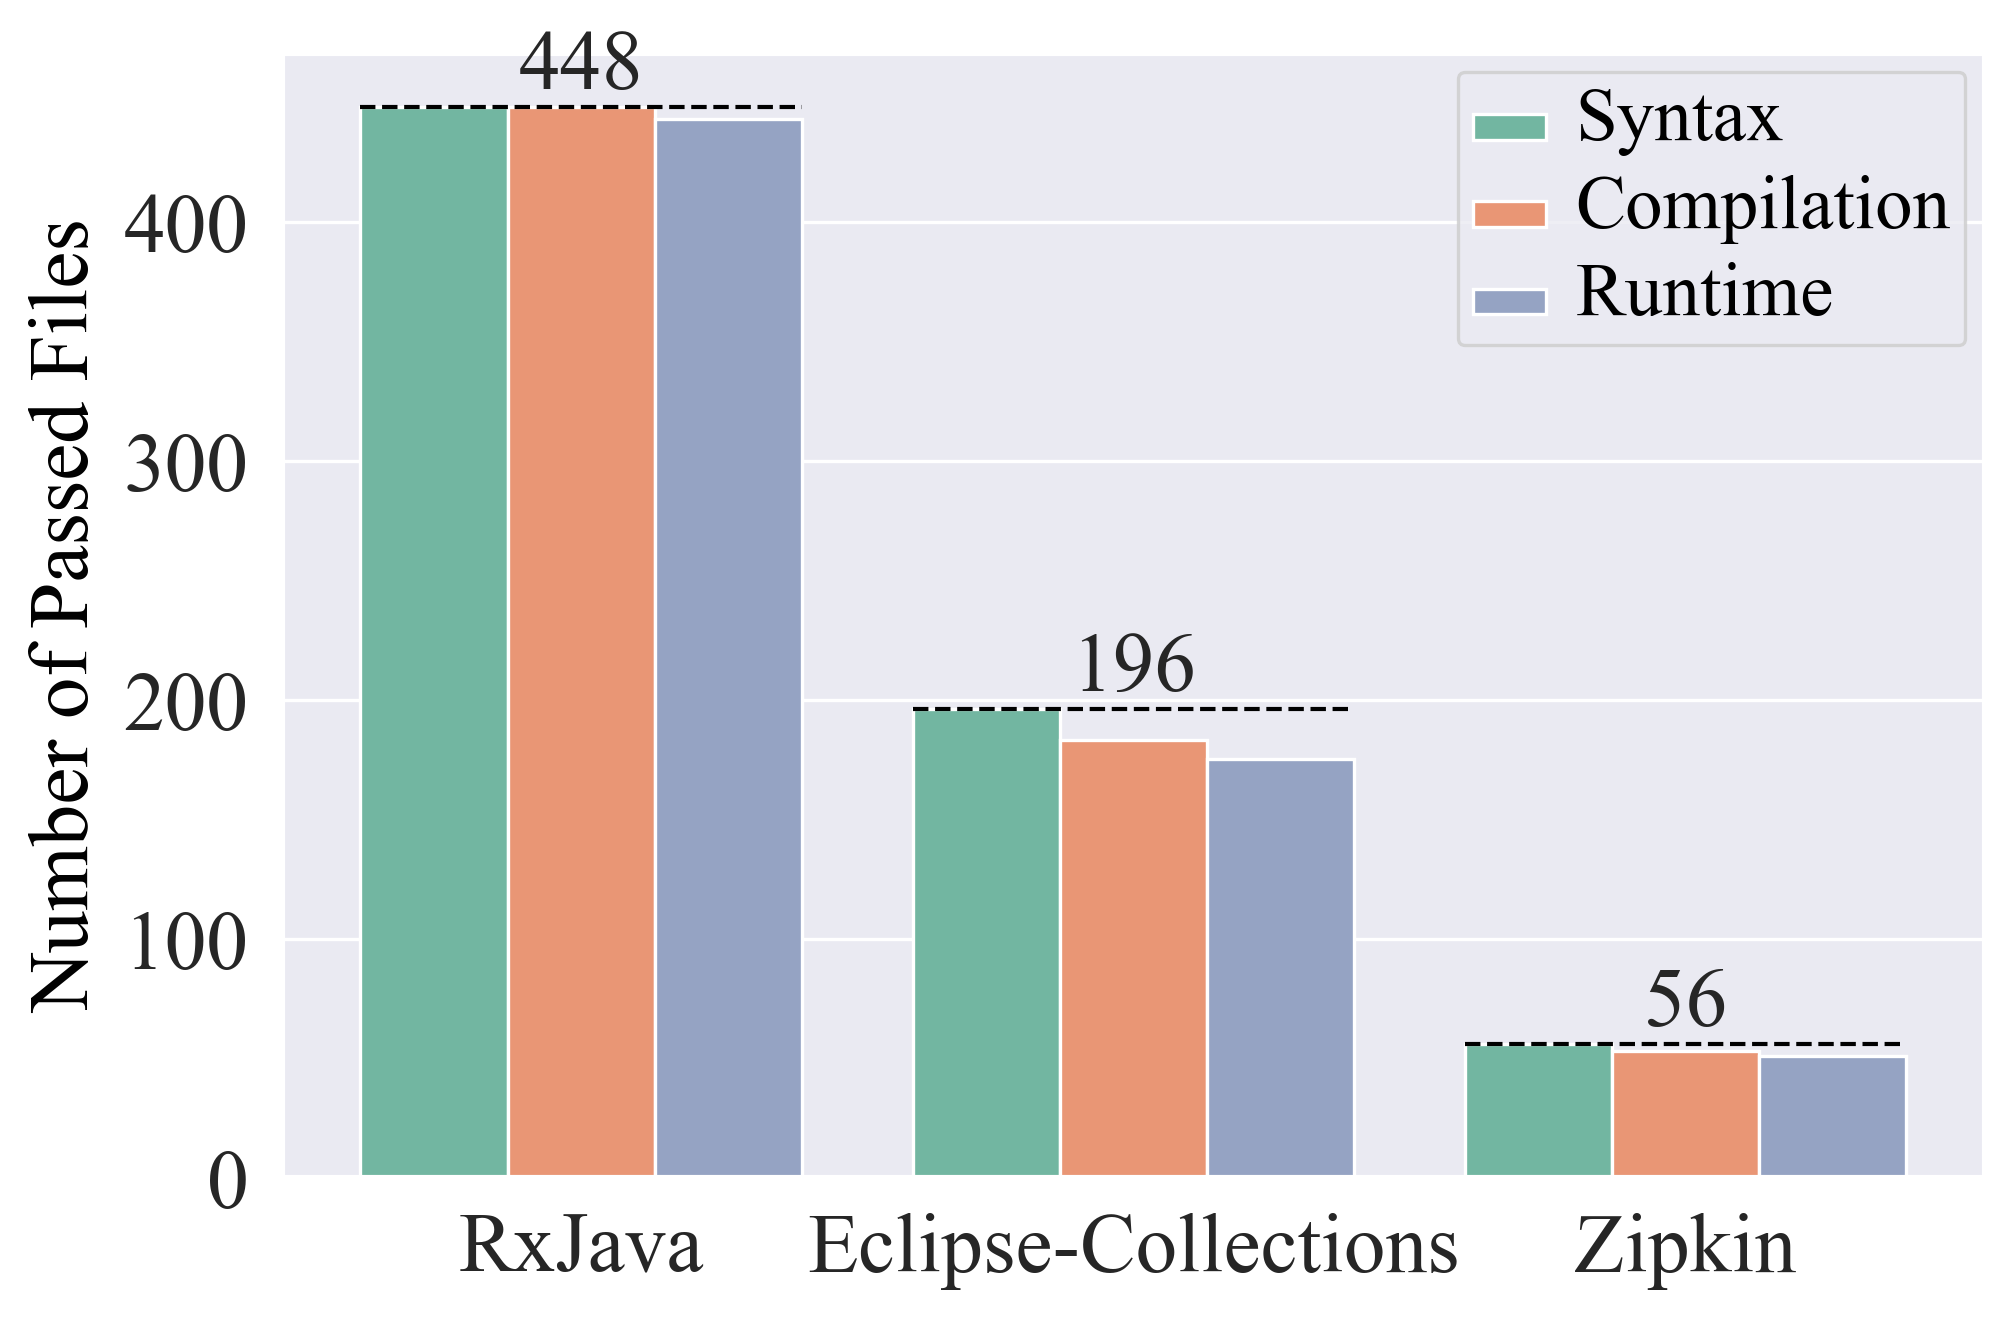

In [14]:
# Pass Rate
rxjava = {
    # 'Qwen2.5-Coder (7B)': {
    #     'Generated': 58,
    #     'Syntax': [58,],
    #     'Compilation': [16, 26, 28],
    #     'Runtime': [28,]
    # },    
    'Qwen2.5-Coder (32B)': {
        'Generated': 138,
        'Syntax': [138, ],
        'Compilation': [88, 116, 125, 135, 136, 136, 137],
        'Runtime': [132,]
    },

    'GPT-OSS (120B)': {
        'Generated': 448,
        'Syntax': [448,],
        'Compilation': [283, 401, 436, 442, 444, 446, 448,],
        'Runtime': [429,443,]
    },
    'Gemini 2.0 Flash': {
        'Generated': 465,
        'Syntax': [465],
        'Compilation': [268, 358, 412, 432, 439, 442,446,448,449],
        'Runtime': [435, 440],
    },
}

eclipse = {
    'Qwen2.5-Coder (7B)': {
        'Generated': 15,
        'Syntax': [14,15],
        'Compilation': [3, 3, 4],
        'Runtime': [3,4]
    }, 
    'Qwen2.5-Coder (32B)': {
        'Generated': 64,
        'Syntax': [64, ],
        'Compilation': [39, 49, 52,54,54,54,55,55,56,],
        'Runtime': [54, 55,]
    },

    'GPT-OSS (120B)': {
        'Generated': 196,
        'Syntax': [191,196],
        'Compilation': [81, 147,162,171,176,178,180,181,181,183],
        'Runtime': [164,174,175,]
    },
    'Gemini 2.0 Flash': {
        'Generated': 202,
        'Syntax': [201, 202],
        'Compilation': [147, 169, 172, 179, 180, 180, 181],
        'Runtime': [174, 177,],
    },
}

zipkin = {
    # 'Qwen2.5-Coder (7B)': {
    #     'Generated': 0,
    #     'Syntax': [0,0],
    #     'Compilation': [0],
    #     'Runtime': [0]
    # },    
    'Qwen2.5-Coder (32B)': {
        'Generated': 29,
        'Syntax': [29,],
        'Compilation': [7,13,16,18,19,],
        'Runtime': [10, 12,]
    },

    'GPT-OSS (120B)': {
        'Generated': 56,
        'Syntax': [55,56],
        'Compilation': [22, 34,45,47,49,50,50,51,53],
        'Runtime': [37,51,]
    },
    'Gemini 2.0 Flash': {
        'Generated': 76,
        'Syntax': [76,],
        'Compilation': [37, 50, 51, 51, 51, 51,51, 51,52, 52],
        'Runtime': [36, 42, ],
    },
}


def padding_to_10(lst):
    while len(lst) < 10:
        lst.append(lst[-1])
    return lst

def normailze(data, project):
    ret = defaultdict(list)
    for model, results in data.items():
        gen = results['Generated']
        results['Syntax'] = padding_to_10(results['Syntax'])
        results['Compilation'] = padding_to_10(results['Compilation'])
        results['Runtime'] = padding_to_10(results['Runtime'])
        total_syn_input = gen
        total_comp_input = results['Syntax'][-1]
        total_run_input = results['Compilation'][-1]

        for attempt, x in enumerate(results['Syntax']):
            ret['Project'].append(project)
            ret['Stage'].append('Syntax')
            ret['Attempt'].append(attempt + 1)
            ret['Model'].append(model)
            ret['Count'].append(results['Syntax'][-1])
            ret['SurvivalRate'].append(results['Syntax'][-1]/total_syn_input*100 if total_syn_input > 0 else 0    )
            ret['Pass'].append(x)
            ret['Err'].append(total_syn_input - x)
            ret['PassRate'].append(x / total_syn_input * 100 if total_syn_input > 0 else 0)
            ret['ErrRate'].append((total_syn_input - x) / total_syn_input * 100 if total_syn_input > 0 else 0)
            ret['InputFiles'].append(total_syn_input)
        for attempt, x in enumerate(results['Compilation']):
            ret['Project'].append(project)
            ret['Stage'].append('Compilation')
            ret['Attempt'].append(attempt + 1)
            ret['Model'].append(model)
            ret['Count'].append(results['Compilation'][-1])
            ret['SurvivalRate'].append(results['Compilation'][-1]/total_comp_input*100 if total_comp_input > 0 else 0    )
            ret['Pass'].append(x)
            ret['Err'].append(total_comp_input - x)
            ret['PassRate'].append(x / total_comp_input * 100 if total_comp_input > 0 else 0)
            ret['ErrRate'].append((total_comp_input - x) / total_comp_input * 100 if total_comp_input > 0 else 0)
            ret['InputFiles'].append(total_comp_input)
        for attempt, x in enumerate(results['Runtime']):
            ret['Project'].append(project)
            ret['Stage'].append('Runtime')
            ret['Attempt'].append(attempt + 1)
            ret['Model'].append(model)
            ret['Count'].append(results['Runtime'][-1])    
            ret['SurvivalRate'].append(results['Runtime'][-1]/total_run_input*100 if total_run_input > 0 else 0    )                   
            ret['Pass'].append(x)
            ret['Err'].append(total_run_input - x)
            ret['PassRate'].append(x / total_run_input * 100 if total_run_input > 0 else 0)
            ret['ErrRate'].append((total_run_input - x) / total_run_input * 100 if total_run_input > 0 else 0)
            ret['InputFiles'].append(total_run_input)
    df = pd.DataFrame(ret)
    return df

df_rxjava = normailze(rxjava, 'RxJava')
df_eclipse = normailze(eclipse, 'Eclipse-Collections')
df_zipkin = normailze(zipkin, 'Zipkin')
df = pd.concat([df_rxjava, df_eclipse, df_zipkin], axis=0, ignore_index=True)
df.head()

figsize = (6.8, 4.5) # best for paper print
model = 'GPT-OSS (120B)'
fig, ax = plt.subplots(figsize=figsize)
times_new_roman = fm.FontProperties(fname=font_path, size=20)

sns.barplot(df[df["Model"] == model], x="Project", y="Count", hue="Stage", ci=None, palette=palette[:3])
stages = 3
for i, project in enumerate(df["Project"].unique()):
    upper_limit = df[(df['Project'] == project) & (df['Model'] == model)]['InputFiles'].max()
    target_value = upper_limit
    # Get the x-center of this group
    group_bars = [patch for gid, patch in enumerate(ax.patches) if gid % stages == i]
    if not group_bars:
        continue
    # Find leftmost and rightmost edges of bars in this group

    left = group_bars[1].get_x() - group_bars[1].get_width() * 1
    right = group_bars[1].get_x() + group_bars[1].get_width() * 2

    # Draw short line just across that group's width
    ax.hlines(y=target_value, xmin=left, xmax=right, color='black', linestyles='dashed', lw=1)
    # Add text label slightly above the line
    ax.text((left+right)/2, target_value+0.3, f"{target_value}", ha='center', va='bottom', fontproperties=times_new_roman)


# plt.xticks(rotation=30, ha='right')  # ha = horizontal alignment
plt.ylabel("Number of Passed Files", fontsize=20, family="Times New Roman", color="black")
plt.xlabel("")  

legend = ax.legend(title=None, frameon=True)
plt.setp(legend.get_texts(), fontsize=18, family="Times New Roman", color="black")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family("Times New Roman")
    label.set_size(20)

plt.tight_layout()
plt.show()

### Impact of Correctness Feedback Chek - RxJava Pass Rates at each Stage (Syntax Checker, Compilation Checker, Runtime Checker)

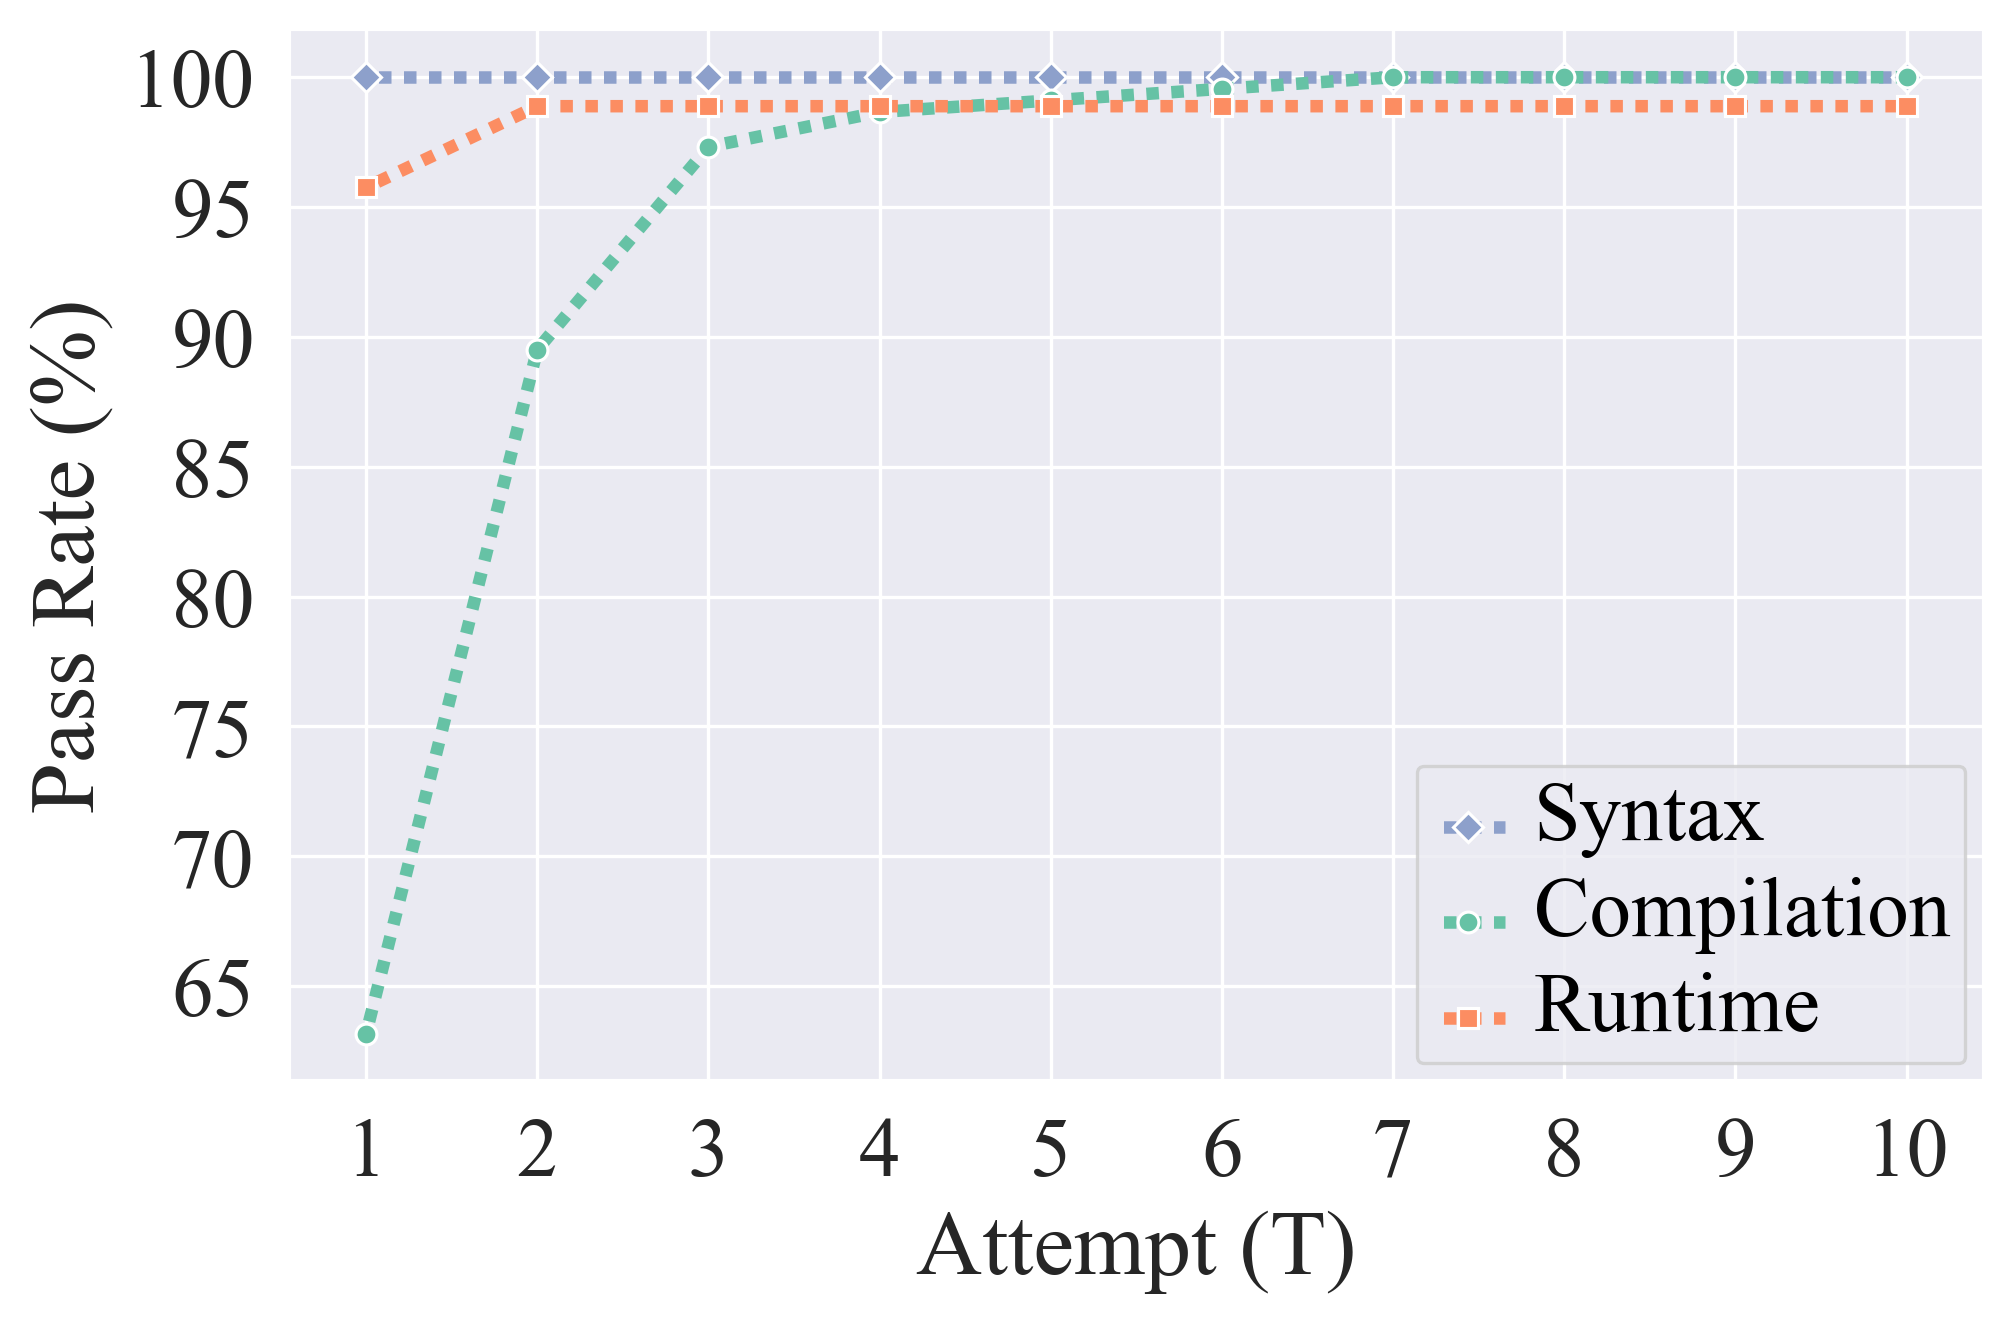

In [ ]:
model = 'GPT-OSS (120B)'
figsize = (6.8, 4.5)                    # best for paper print

fig, ax = plt.subplots(figsize=figsize)

times_new_roman = fm.FontProperties(fname=font_path, size=22)


marker_type = {
    "Compilation": "o",   # circle
    "Runtime": "s",       # square
    "Syntax": "D"         # diamond
}
colors = {
    "RxJava": palette[0],
    "Eclipse-Collections": palette[1],
    "Zipkin": palette[2],
}
colors = {
    "Compilation": palette[0],
    "Runtime": palette[1],
    "Syntax": palette[2],
}
linestyles = {
    "RxJava":    (0, (1, 1)),   # dotted
    "Eclipse-Collections": (0, (5, 2)), # dashed
    "Zipkin":     (0, ()),     # solid
}

linestyles = {
    "RxJava": (3, (1, 1)),   # dotted
    "Eclipse-Collections": (3, (5, 2)), # dashed
    "Zipkin":     (3, ()),     # solid
}

target_project = 'RxJava'
for stage in ['Syntax', 'Compilation', 'Runtime']:
    for project in df['Project'].unique():     
        if project != target_project:
            continue
        new_df = df[(df["Model"] == model) & (df["Stage"] == stage) & (df["Project"] == project)]
        sns.lineplot(new_df, x="Attempt", y="PassRate",
                     label=f"{stage}",
                     marker=marker_type[stage],
                     markersize=5,
                     errorbar=None,
                     linestyle=linestyles[project],
                     linewidth=3,
                     color=colors[stage])
        
plt.ylabel("Pass Rate (%)", fontproperties=times_new_roman)
plt.xlabel("Attempt (T)", fontproperties=times_new_roman)  
plt.xticks(range(1, 11))


legend = ax.legend(title=None, frameon=True,  ncol=1)
plt.setp(legend.get_texts(), fontsize=20, family="Times New Roman", color="black")


for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family("Times New Roman")
    label.set_size(20)

plt.tight_layout()
plt.show()

### Impact of Correctness Feedback Chek - Eclipse-Collections Pass Rates at each Stage (Syntax Checker, Compilation Checker, Runtime Checker)

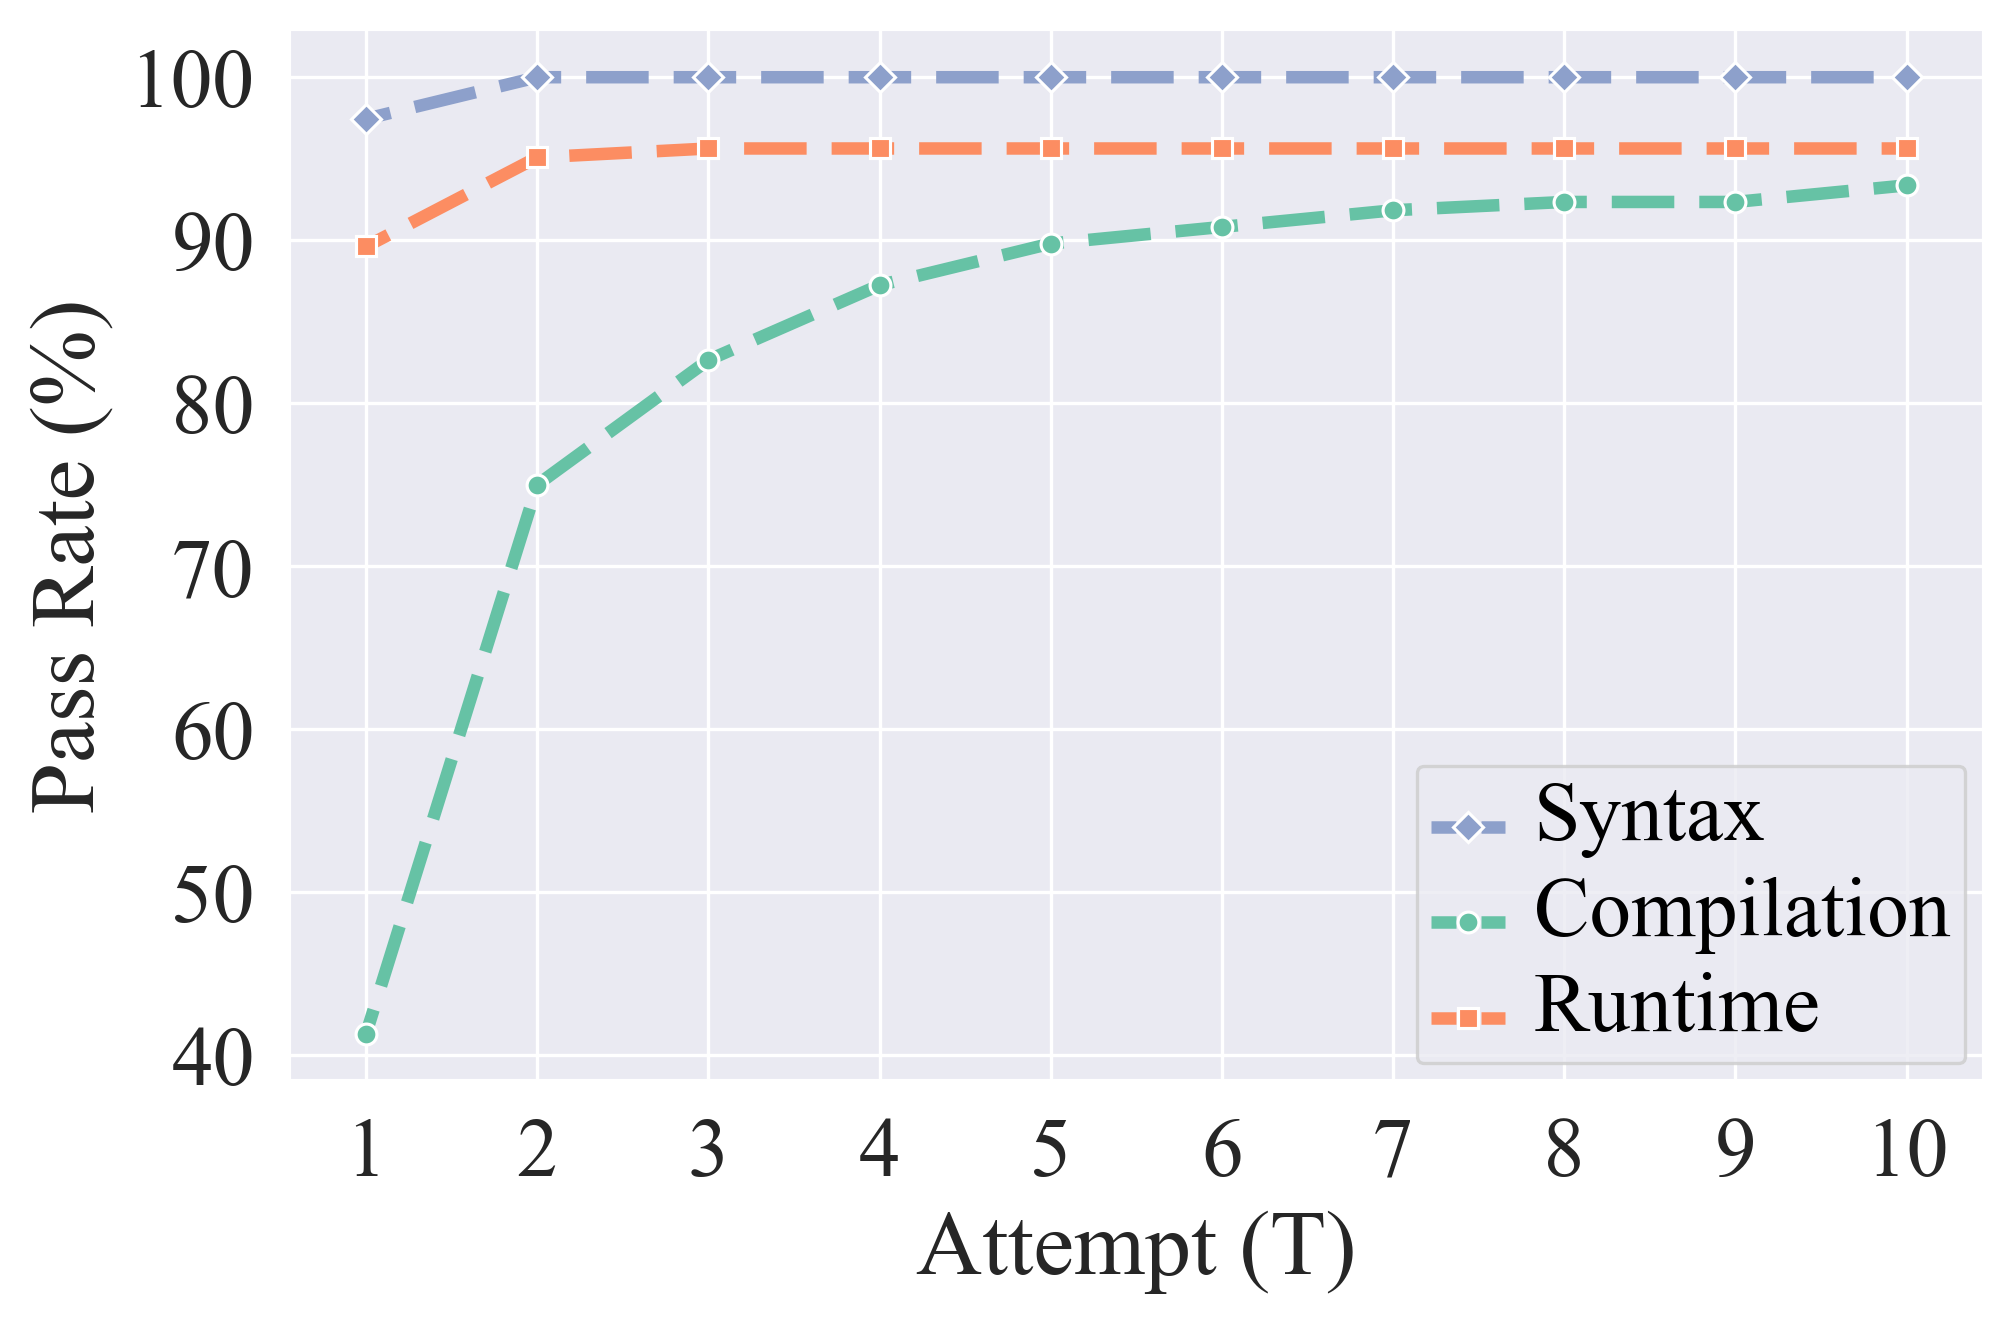

In [17]:
model = 'GPT-OSS (120B)'
figsize = (6.8, 4.5)                    # best for paper print

fig, ax = plt.subplots(figsize=figsize)

times_new_roman = fm.FontProperties(fname=font_path, size=22)


marker_type = {
    "Compilation": "o",   # circle
    "Runtime": "s",       # square
    "Syntax": "D"         # diamond
}
colors = {
    "RxJava": palette[0],
    "Eclipse-Collections": palette[1],
    "Zipkin": palette[2],
}
colors = {
    "Compilation": palette[0],
    "Runtime": palette[1],
    "Syntax": palette[2],
}
linestyles = {
    "RxJava":    (0, (1, 1)),   # dotted
    "Eclipse-Collections": (0, (5, 2)), # dashed
    "Zipkin":     (0, ()),     # solid
}

linestyles = {
    "RxJava": (3, (1, 1)),   # dotted
    "Eclipse-Collections": (3, (5, 2)), # dashed
    "Zipkin":     (3, ()),     # solid
}

target_project = 'Eclipse-Collections'
for stage in ['Syntax', 'Compilation', 'Runtime']:
    for project in df['Project'].unique():     
        if project != target_project:
            continue
        new_df = df[(df["Model"] == model) & (df["Stage"] == stage) & (df["Project"] == project)]
        sns.lineplot(new_df, x="Attempt", y="PassRate",
                     label=f"{stage}",
                     marker=marker_type[stage],
                     markersize=5,
                     errorbar=None,
                     linestyle=linestyles[project],
                     linewidth=3,
                     color=colors[stage])
        
plt.ylabel("Pass Rate (%)", fontproperties=times_new_roman)
plt.xlabel("Attempt (T)", fontproperties=times_new_roman)  
plt.xticks(range(1, 11))


legend = ax.legend(title=None, frameon=True,  ncol=1)
plt.setp(legend.get_texts(), fontsize=20, family="Times New Roman", color="black")


for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family("Times New Roman")
    label.set_size(20)

plt.tight_layout()
plt.show()

### Impact of Correctness Feedback Chek - Zipkin Pass Rates at each Stage (Syntax Checker, Compilation Checker, Runtime Checker)

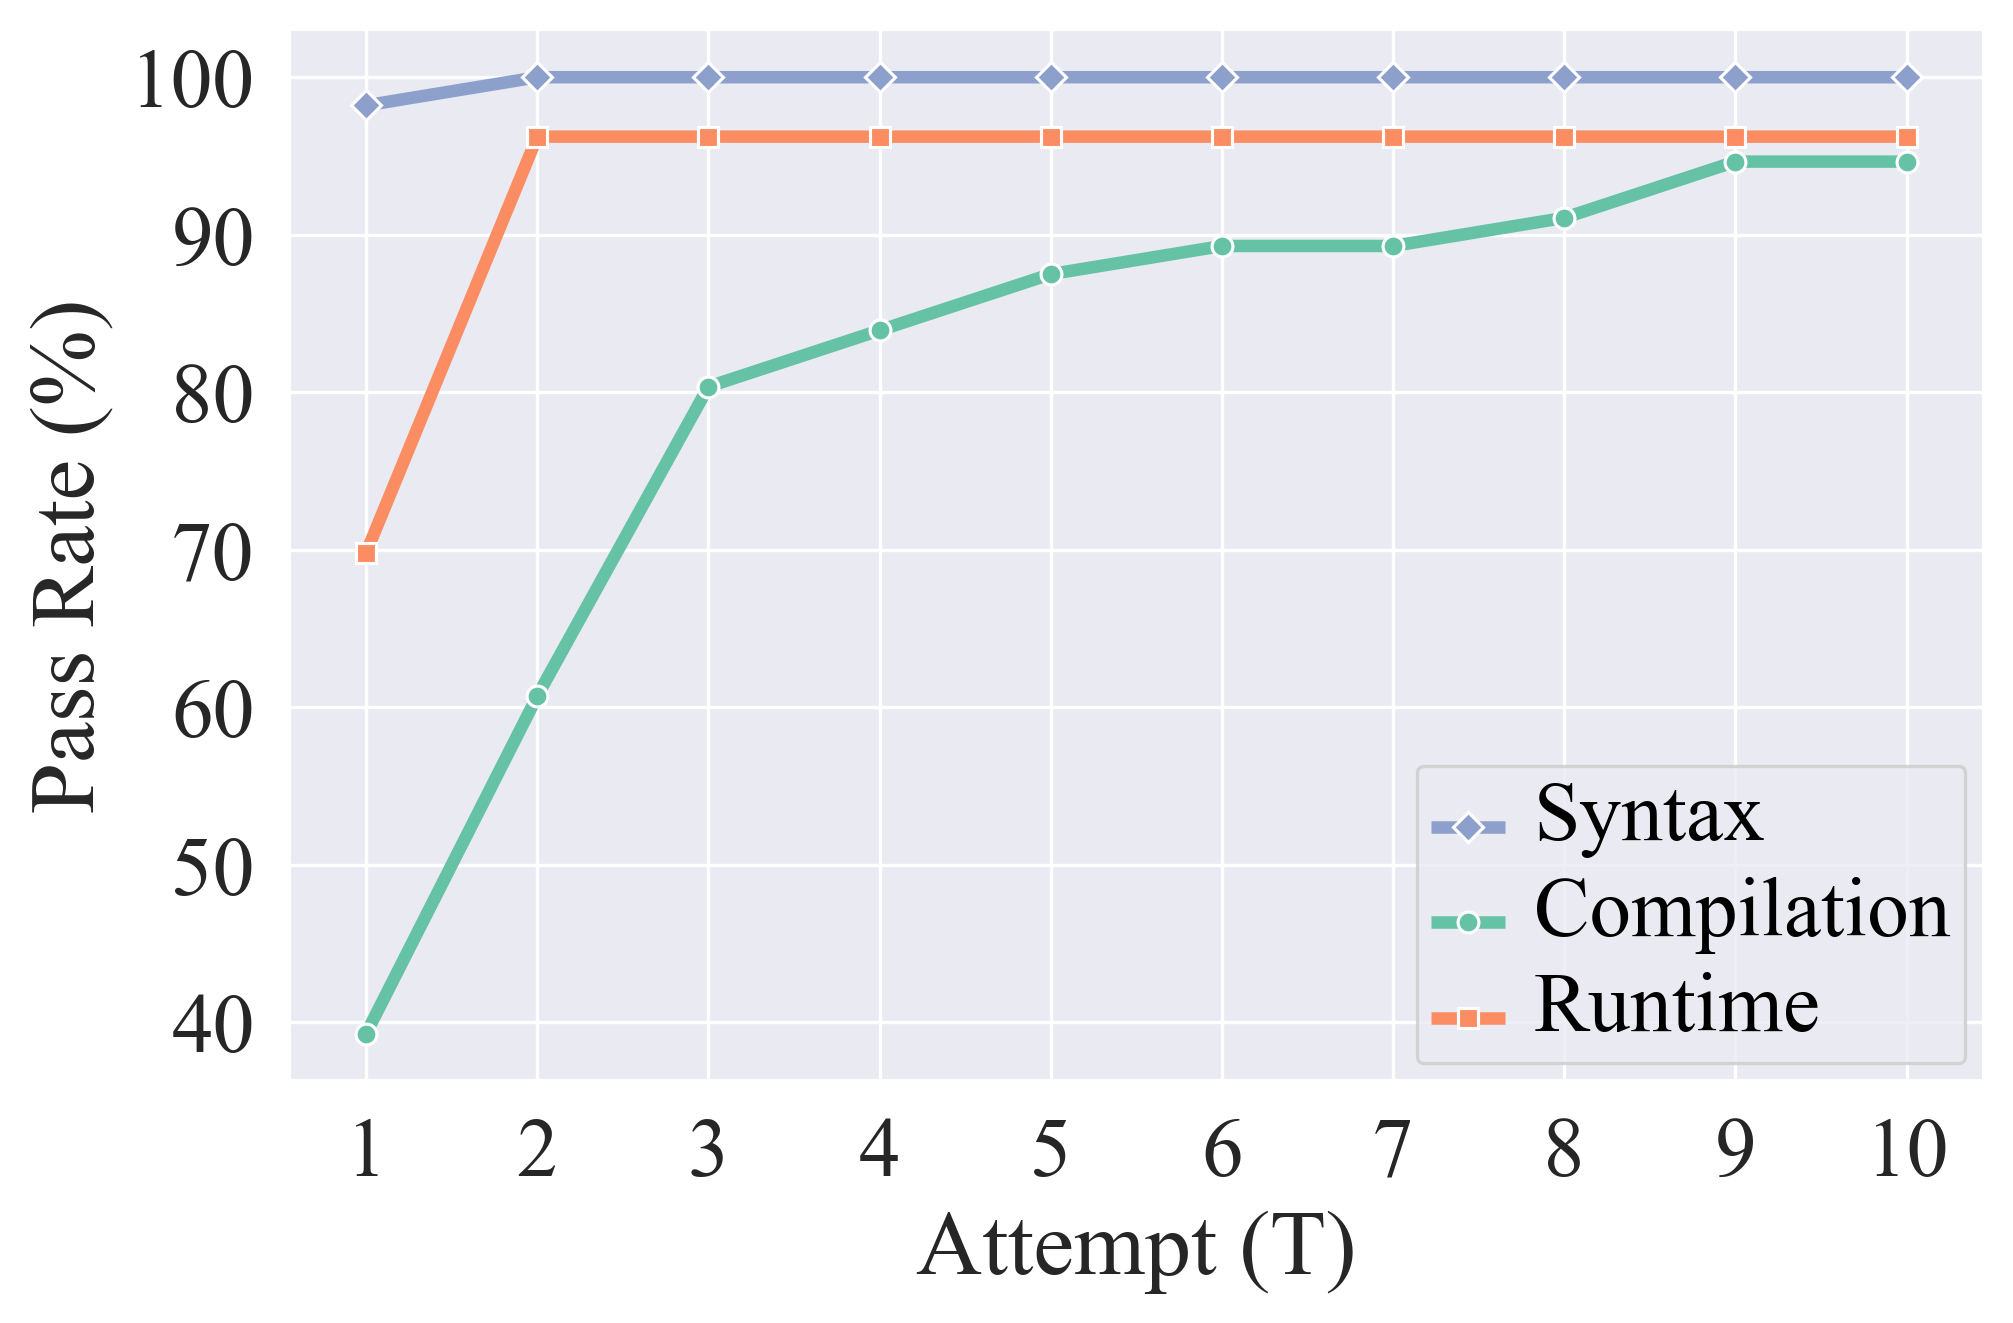

In [18]:
model = 'GPT-OSS (120B)'
figsize = (6.8, 4.5)                    # best for paper print

fig, ax = plt.subplots(figsize=figsize)

times_new_roman = fm.FontProperties(fname=font_path, size=22)


marker_type = {
    "Compilation": "o",   # circle
    "Runtime": "s",       # square
    "Syntax": "D"         # diamond
}
colors = {
    "RxJava": palette[0],
    "Eclipse-Collections": palette[1],
    "Zipkin": palette[2],
}
colors = {
    "Compilation": palette[0],
    "Runtime": palette[1],
    "Syntax": palette[2],
}
linestyles = {
    "RxJava":    (0, (1, 1)),   # dotted
    "Eclipse-Collections": (0, (5, 2)), # dashed
    "Zipkin":     (0, ()),     # solid
}

linestyles = {
    "RxJava": (3, (1, 1)),   # dotted
    "Eclipse-Collections": (3, (5, 2)), # dashed
    "Zipkin":     (3, ()),     # solid
}

target_project = 'Zipkin'
for stage in ['Syntax', 'Compilation', 'Runtime']:
    for project in df['Project'].unique():     
        if project != target_project:
            continue
        new_df = df[(df["Model"] == model) & (df["Stage"] == stage) & (df["Project"] == project)]
        sns.lineplot(new_df, x="Attempt", y="PassRate",
                     label=f"{stage}",
                     marker=marker_type[stage],
                     markersize=5,
                     errorbar=None,
                     linestyle=linestyles[project],
                     linewidth=3,
                     color=colors[stage])
        
plt.ylabel("Pass Rate (%)", fontproperties=times_new_roman)
plt.xlabel("Attempt (T)", fontproperties=times_new_roman)  
plt.xticks(range(1, 11))


legend = ax.legend(title=None, frameon=True,  ncol=1)
plt.setp(legend.get_texts(), fontsize=20, family="Times New Roman", color="black")


for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family("Times New Roman")
    label.set_size(20)

plt.tight_layout()
plt.show()

### Impact of different LLMs

In [ ]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
llm_model = 'gptoss-120b'
bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{llm_model}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]], method: str):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    for branch, bug_sizes in branch_to_bug_sizes.items():
        name = branch
        bug_sizes = np.array(bug_sizes)
        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            print(f"{name} ({method})):\t bug_size {bug_size * 100} %: ratio of cases killed the mutant: {detected.shape[-1]/bug_sizes.shape[-1]*100:.2f} %")
        print('-'*30)

path = Path(f'../Data/RQ3/{project}-common_methods_details_jmh_ju2jmh_llm2jmh.csv')
df = pd.read_csv(str(path))
branch_to_method_to_to_cases = {
    'jmh': {},
    'ju2jmh': {},
    'llm2jmh': {},
}
branch_to_involved_cases = defaultdict(set)

for i, row in df.iterrows():
    method, line = eval(row['method'])
    method = method.replace('$', '-')
    method = f'{method}_{line}'
    branch_to_method_to_to_cases['jmh'][method] = row['jmh'].split('|')
    branch_to_method_to_to_cases['ju2jmh'][method] = row['ju2jmh'].split('|')
    branch_to_method_to_to_cases['llm2jmh'][method] = row['llm2jmh'].split('|')

# for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
#     if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
#         continue
          
#     detect_bug_size_ratio(branch_to_bug_sizes, method) 
#     print('>'*30)

branch_to_all_bug_sizes = defaultdict(list)

total_bugs = 0

for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
    if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
        continue

    total_bugs += 1    
    for branch, bug_sizes in branch_to_bug_sizes.items():
        branch_to_involved_cases[branch].update(set(branch_to_method_to_to_cases[branch][method]))
        branch_to_all_bug_sizes[branch].extend(bug_sizes)

detect_bug_size_ratio(branch_to_all_bug_sizes, 'ALL') 

# print(f"involved cases for jmh: {len(branch_to_involved_cases['jmh'])}")
# print(f"involved cases for ju2jmh: {len(branch_to_involved_cases['ju2jmh'])}")
# print(f"involved cases for llm2jmh: {len(branch_to_involved_cases['llm2jmh'])}")
print(f'Total bugs: {total_bugs}')

### False-Positive Rate in LLM4JMH

In [ ]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
bug_size_path = Path(f'../Data/FPR/{project}-bug.json')

with open(bug_size_path, 'r') as fp:
    method_to_branch_to_bug_sizes = json.load(fp)

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]], method: str):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]
    for branch, bug_sizes in branch_to_bug_sizes.items():
        name = branch
        bug_sizes = np.array(bug_sizes)
        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            print(f"{name} ({method})):\t bug_size {bug_size * 100} %: ratio of cases killed the mutant: {detected.shape[-1]/bug_sizes.shape[-1]*100:.2f} %")
        print('-'*30)

path = Path(f'../Data/RQ3/{project}-common_methods_details_jmh_ju2jmh_llm2jmh.csv')
df = pd.read_csv(str(path))
branch_to_method_to_to_cases = {
    'jmh': {},
    'ju2jmh': {},
    'llm2jmh': {},
}
branch_to_involved_cases = defaultdict(set)

for i, row in df.iterrows():
    method, line = eval(row['method'])
    method = method.replace('$', '-')
    method = f'{method}_{line}'
    branch_to_method_to_to_cases['jmh'][method] = row['jmh'].split('|')
    branch_to_method_to_to_cases['ju2jmh'][method] = row['ju2jmh'].split('|')
    branch_to_method_to_to_cases['llm2jmh'][method] = row['llm2jmh'].split('|')

# for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
#     if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
#         continue
          
#     detect_bug_size_ratio(branch_to_bug_sizes, method) 
#     print('>'*30)

branch_to_all_bug_sizes = defaultdict(list)

total_bugs = 0

for method, branch_to_bug_sizes in method_to_branch_to_bug_sizes.items():
    if len(branch_to_bug_sizes['jmh']) == 0 or len(branch_to_bug_sizes['ju2jmh']) == 0 or len(branch_to_bug_sizes['llm2jmh']) == 0:
        continue

    total_bugs += 1    
    for branch, bug_sizes in branch_to_bug_sizes.items():
        branch_to_involved_cases[branch].update(set(branch_to_method_to_to_cases[branch][method]))
        branch_to_all_bug_sizes[branch].extend(bug_sizes)

detect_bug_size_ratio(branch_to_all_bug_sizes, 'ALL') 

# print(f"involved cases for jmh: {len(branch_to_involved_cases['jmh'])}")
# print(f"involved cases for ju2jmh: {len(branch_to_involved_cases['ju2jmh'])}")
# print(f"involved cases for llm2jmh: {len(branch_to_involved_cases['llm2jmh'])}")
print(f'Total bugs: {total_bugs}')

### 5.3 Impact of different LLMs - RxJava (GPTOSS-120B)

In [28]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
model = 'gptoss'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (1970)====================
| branch         |       1 |       5 |      10 |     50 |      90 |
|----------------|---------|---------|---------|--------|---------|
| GPT-OSS (120B) | 62.7919 | 57.2589 | 54.6193 | 44.467 | 36.3452 |
==================== Percentage of detected bugs (15) ====================
| branch         |   1 |   5 |   10 |   50 |   90 |
|----------------|-----|-----|------|------|------|
| GPT-OSS (120B) | 100 | 100 |  100 |  100 |  100 |
==================== Percentage of killed mutants (1970)====================
| branch           |       1 |       5 |      10 |     50 |      90 |
|------------------|---------|---------|---------|--------|---------|
| Gemini 2.0 Flash | 62.7919 | 57.2589 | 54.6193 | 44.467 | 36.3452 |
==================== Percentage of detected bugs (15) ====================
| branch           |   1 |   5 |   10 |   50 |   90 |
|------------------|-----|-----|------|------|------|
| Gemini 2.0 Flash

### 5.3 Impact of different LLMs - RxJava (Gemini)

In [29]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
model = 'gemini'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (3154)====================
| branch         |       1 |      5 |      10 |      50 |      90 |
|----------------|---------|--------|---------|---------|---------|
| GPT-OSS (120B) | 74.2549 | 70.577 | 68.8649 | 59.0996 | 46.0051 |
==================== Percentage of detected bugs (15) ====================
| branch         |   1 |   5 |   10 |   50 |   90 |
|----------------|-----|-----|------|------|------|
| GPT-OSS (120B) | 100 | 100 |  100 |  100 |  100 |
==================== Percentage of killed mutants (3154)====================
| branch           |       1 |      5 |      10 |      50 |      90 |
|------------------|---------|--------|---------|---------|---------|
| Gemini 2.0 Flash | 74.2549 | 70.577 | 68.8649 | 59.0996 | 46.0051 |
==================== Percentage of detected bugs (15) ====================
| branch           |   1 |   5 |   10 |   50 |   90 |
|------------------|-----|-----|------|------|------|
| Gemini 2.0 Flash

### 5.3 Impact of different LLMs - RxJava (Qwen2.5-Coder-32B)

In [30]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'rxjava'
model = 'qwen'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (284)====================
| branch         |       1 |       5 |      10 |      50 |      90 |
|----------------|---------|---------|---------|---------|---------|
| GPT-OSS (120B) | 79.2254 | 76.0563 | 74.6479 | 66.1972 | 51.7606 |
==================== Percentage of detected bugs (15) ====================
| branch         |   1 |   5 |   10 |      50 |   90 |
|----------------|-----|-----|------|---------|------|
| GPT-OSS (120B) | 100 | 100 |  100 | 93.3333 |   80 |
==================== Percentage of killed mutants (284)====================
| branch           |       1 |       5 |      10 |      50 |      90 |
|------------------|---------|---------|---------|---------|---------|
| Gemini 2.0 Flash | 79.2254 | 76.0563 | 74.6479 | 66.1972 | 51.7606 |
==================== Percentage of detected bugs (15) ====================
| branch           |   1 |   5 |   10 |      50 |   90 |
|------------------|-----|-----|------|---------|------|

### 5.3 Impact of different LLMs - Eclipse-Collections (GPTOSS-120B)

In [27]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'eclipse-collections'
model = 'gptoss'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (867)====================
| branch         |      1 |       5 |      10 |   50 |   90 |
|----------------|--------|---------|---------|------|------|
| GPT-OSS (120B) | 16.955 | 3.69089 | 1.38408 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch         |       1 |       5 |      10 |   50 |   90 |
|----------------|---------|---------|---------|------|------|
| GPT-OSS (120B) | 90.9091 | 81.8182 | 54.5455 |    0 |    0 |
==================== Percentage of killed mutants (867)====================
| branch           |      1 |       5 |      10 |   50 |   90 |
|------------------|--------|---------|---------|------|------|
| Gemini 2.0 Flash | 16.955 | 3.69089 | 1.38408 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch           |       1 |       5 |      10 |   50 |   90 |
|------------------|---------|---------|---------|------|------|
|

### 5.3 Impact of different LLMs - Eclipse-Collections (Gemini)

In [31]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'eclipse-collections'
model = 'gemini'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (701)====================
| branch         |       1 |       5 |      10 |   50 |   90 |
|----------------|---------|---------|---------|------|------|
| GPT-OSS (120B) | 15.8345 | 3.42368 | 1.99715 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch         |   1 |       5 |      10 |   50 |   90 |
|----------------|-----|---------|---------|------|------|
| GPT-OSS (120B) | 100 | 63.6364 | 36.3636 |    0 |    0 |
==================== Percentage of killed mutants (701)====================
| branch           |       1 |       5 |      10 |   50 |   90 |
|------------------|---------|---------|---------|------|------|
| Gemini 2.0 Flash | 15.8345 | 3.42368 | 1.99715 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch           |   1 |       5 |      10 |   50 |   90 |
|------------------|-----|---------|---------|------|------|
| Gemini 2.0 Fl

### 5.3 Impact of different LLMs - Eclipse-Collections (Qwen2.5-Coder-32B)

In [32]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'eclipse-collections'
model = 'qwen'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (91)====================
| branch         |      1 |   5 |   10 |   50 |   90 |
|----------------|--------|-----|------|------|------|
| GPT-OSS (120B) | 10.989 |   0 |    0 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch         |       1 |   5 |   10 |   50 |   90 |
|----------------|---------|-----|------|------|------|
| GPT-OSS (120B) | 63.6364 |   0 |    0 |    0 |    0 |
==================== Percentage of killed mutants (91)====================
| branch           |      1 |   5 |   10 |   50 |   90 |
|------------------|--------|-----|------|------|------|
| Gemini 2.0 Flash | 10.989 |   0 |    0 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch           |       1 |   5 |   10 |   50 |   90 |
|------------------|---------|-----|------|------|------|
| Gemini 2.0 Flash | 63.6364 |   0 |    0 |    0 |    0 |
==================== P

### 5.3 Impact of different LLMs - Zipkin (GPT-120B)

In [33]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'zipkin'
model = 'gptoss'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (610)====================
| branch         |       1 |       5 |      10 |   50 |   90 |
|----------------|---------|---------|---------|------|------|
| GPT-OSS (120B) | 14.7541 | 2.95082 | 1.63934 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch         |       1 |       5 |      10 |   50 |   90 |
|----------------|---------|---------|---------|------|------|
| GPT-OSS (120B) | 81.8182 | 54.5455 | 54.5455 |    0 |    0 |
==================== Percentage of killed mutants (610)====================
| branch           |       1 |       5 |      10 |   50 |   90 |
|------------------|---------|---------|---------|------|------|
| Gemini 2.0 Flash | 14.7541 | 2.95082 | 1.63934 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch           |       1 |       5 |      10 |   50 |   90 |
|------------------|---------|---------|---------|------|---

### 5.3 Impact of different LLMs - Zipkin (Gemini)

In [34]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'zipkin'
model = 'gemini'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (195)====================
| branch         |       1 |       5 |      10 |   50 |   90 |
|----------------|---------|---------|---------|------|------|
| GPT-OSS (120B) | 21.5385 | 5.12821 | 1.02564 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch         |       1 |       5 |      10 |   50 |   90 |
|----------------|---------|---------|---------|------|------|
| GPT-OSS (120B) | 81.8182 | 36.3636 | 18.1818 |    0 |    0 |
==================== Percentage of killed mutants (195)====================
| branch           |       1 |       5 |      10 |   50 |   90 |
|------------------|---------|---------|---------|------|------|
| Gemini 2.0 Flash | 21.5385 | 5.12821 | 1.02564 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch           |       1 |       5 |      10 |   50 |   90 |
|------------------|---------|---------|---------|------|---

### 5.3 Impact of different LLMs - Zipkin (Qwen2.5-Coder-32B)

In [35]:
import json
from pathlib import Path
from typing import Dict, List, Optional
import numpy as np
from collections import defaultdict

project = 'zipkin'
model = 'qwen'

bug_size_path = Path(f'../Data/Impact-of-LLM/{project}-{model}-bug.json')
branch_to_bug_sizes = json.loads(bug_size_path.read_text())

def detect_bug_size_ratio(branch_to_bug_sizes: Dict[str, List[float]]):
    bug_size_thresholds = [0.01, 0.05, 0.1, 0.5, 0.9]

    total_bugs = 0
    total_benchmarks = 0
    bug_size_to_killed_mutants = defaultdict(int)
    bug_size_to_detected_bug = defaultdict(int)
    # NOTE: buggy branch
    for branch, bug_sizes in branch_to_bug_sizes.items():
        bug_sizes = np.array(bug_sizes)
        total_benchmarks += len(bug_sizes)
        # if branch not in branch_to_bug_size_to_detected:
        #     branch_to_bug_size_to_detected[branch] = defaultdict(int)

        for bug_size in bug_size_thresholds:
            detected = bug_sizes[bug_sizes >= bug_size]
            bug_size_to_killed_mutants[bug_size] += detected.shape[-1]
            # if detected.shape[-1] > 0:
            #     branch_to_bug_size_to_detected[branch][bug_size] += 1
            bug_size_to_detected_bug[bug_size] += (detected.shape[-1] > 0)
        total_bugs += 1

    return bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks


for branch in ['GPT-OSS (120B)', 'Gemini 2.0 Flash', 'Qwen2.5-Coder (32B)']:
    bug_size_to_detected_bug, bug_size_to_killed_mutants, total_bugs, total_benchmarks = detect_bug_size_ratio(branch_to_bug_sizes)
    from tabulate import tabulate
    print(f"==================== Percentage of killed mutants ({total_benchmarks})====================")
    data = [branch]
    headers = ['branch']

    for bug_size, detected in bug_size_to_killed_mutants.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_benchmarks * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))

    print(f"==================== Percentage of detected bugs ({total_bugs}) ====================")
    data = [branch]
    headers = ['branch']
    for bug_size, detected in bug_size_to_detected_bug.items():
        headers.append(int(bug_size * 100))
        data.append(detected/total_bugs * 100)

    print(tabulate([data], headers=headers, tablefmt="github"))


==================== Percentage of killed mutants (29)====================
| branch         |       1 |       5 |   10 |   50 |   90 |
|----------------|---------|---------|------|------|------|
| GPT-OSS (120B) | 3.44828 | 3.44828 |    0 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch         |       1 |       5 |   10 |   50 |   90 |
|----------------|---------|---------|------|------|------|
| GPT-OSS (120B) | 9.09091 | 9.09091 |    0 |    0 |    0 |
==================== Percentage of killed mutants (29)====================
| branch           |       1 |       5 |   10 |   50 |   90 |
|------------------|---------|---------|------|------|------|
| Gemini 2.0 Flash | 3.44828 | 3.44828 |    0 |    0 |    0 |
==================== Percentage of detected bugs (11) ====================
| branch           |       1 |       5 |   10 |   50 |   90 |
|------------------|---------|---------|------|------|------|
| Gemini 2.0 Flash | 9.09091 |